In [1]:
# @title Dashboard: Mapa de Susceptibilidad de Incendios Forestales en Córdoba
from IPython.display import HTML, display
import os

DASHBOARD_HTML = '''

<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');

:root {
  --bg0:    #050505;
  --bg1:    #0f0f0f;
  --bg2:    #141414;
  --bg3:    #1f1f1f;
  --border: rgba(255, 140, 0, 0.15);
  --ink:    #f5f5f5;
  --muted:  #a3a3a3;
  --dim:    #5c5c5c;
  --orange: #ff8c00;
  --orange-light: #ffb347;
  --gold:   #f5c542;
  --red:    #ff4d4d;
}

*, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

body {
  font-family: 'Space Grotesk', sans-serif;
  background: var(--bg0);
  color: var(--ink);
  padding: 0;
  margin: 0;
  line-height: 1.6;
}

.shell {
  max-width: 1200px;
  margin: 0 auto;
  padding: 30px 20px 50px;
}

/* ── Header ─────────────────────────────────── */
header {
  display: flex;
  justify-content: space-between;
  align-items: flex-start;
  gap: 16px;
  flex-wrap: wrap;
  margin-bottom: 30px;
  padding-bottom: 20px;
  border-bottom: 1px solid var(--border);
}
.logo-group { display: flex; flex-direction: column; gap: 8px; flex: 1; }
.logo-row { display: flex; align-items: center; gap: 12px; }
.pulse {
  width: 12px; height: 12px; border-radius: 50%;
  background: var(--orange);
  box-shadow: 0 0 14px var(--orange);
  animation: pulse 2s infinite;
}
@keyframes pulse { 0%,100%{opacity:1;transform:scale(1)} 50%{opacity:.5;transform:scale(.7)} }
h1 { font-size: 2rem; font-weight: 700; letter-spacing: -.5px; margin: 0; line-height: 1.2;}
h1 span { color: var(--orange); }
.authors { font-size: 1rem; color: var(--orange-light); font-weight: 500; margin-top: 4px; }
.subtitle { font-size: 0.85rem; color: var(--muted); text-transform: uppercase; letter-spacing: 1px; margin-top: 4px; }

.header-badges { display: flex; gap: 8px; flex-wrap: wrap; align-items: center; }
.badge {
  font-size: .75rem; font-weight: 600; letter-spacing: .5px;
  padding: 6px 12px; border-radius: 20px;
  background: var(--bg3); border: 1px solid var(--border);
  color: var(--muted);
}
.badge.highlight { border-color: var(--orange); color: var(--orange); }

/* ── KPI cards ──────────────────────────────── */
.kpi-row {
  display: grid;
  grid-template-columns: repeat(2, 1fr);
  gap: 16px;
  margin-bottom: 30px;
}
@media(max-width:900px){ .kpi-row{ grid-template-columns: 1fr; } }

.kpi {
  background: var(--bg2);
  border: 1px solid var(--border);
  border-radius: 12px;
  padding: 16px 20px;
  position: relative; overflow: hidden;
  box-shadow: 0 4px 15px rgba(0,0,0,0.3);
}
.kpi::before {
  content: '';
  position: absolute; top: 0; left: 0; right: 0; height: 3px;
  background: var(--accent-line, var(--orange));
}
.kpi .k-label { font-size: .75rem; font-weight: 600; color: var(--muted); text-transform: uppercase; letter-spacing: .6px; }
.kpi .k-val   { font-size: 1.8rem; font-weight: 700; margin-top: 6px; font-family: 'JetBrains Mono', monospace; color: var(--orange); }
.kpi .k-sub   { font-size: .8rem; color: var(--dim); margin-top: 2px; }

/* ── Main panels ────────────────────────────── */
.panel {
  background: var(--bg2);
  border: 1px solid var(--border);
  border-radius: 16px;
  padding: 24px;
  margin-bottom: 24px;
  box-shadow: 0 8px 25px rgba(255, 140, 0, 0.05);
}
.panel-title {
  font-size: 1rem; font-weight: 700;
  text-transform: uppercase; letter-spacing: 1px;
  color: var(--orange-light); margin-bottom: 16px;
  display: flex; align-items: center; gap: 10px;
}
.panel-title .dot {
  width: 8px; height: 8px; border-radius: 50%;
  background: var(--orange);
  box-shadow: 0 0 10px var(--orange);
}
.summary-text {
  font-size: 1.1rem;
  line-height: 1.8;
  color: #d1d1d1;
  text-align: justify;
}

/* ── Obj & Hip Grid ─────────────────────────── */
.obj-hip-grid {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 20px;
  margin-bottom: 24px;
}
@media(max-width:900px){ .obj-hip-grid{ grid-template-columns: 1fr; } }
.obj-hip-grid .panel { margin-bottom: 0; }

/* ── Reference Cards ────────────────────────── */
.cards-wrap {
  display: grid;
  gap: 20px;
  margin-top: 20px;
}

.mag-card {
  padding: 20px 24px;
  border-radius: 16px;
  background: var(--bg1);
  border: 1px solid var(--border);
  border-left: 4px solid var(--orange);
  box-shadow: 0 10px 30px rgba(0,0,0,0.2);
  position: relative;
  opacity: 0;
  transform: translateY(18px);
  animation: riseIn .6s ease forwards;
  display: flex;
  flex-direction: column;
  justify-content: center;
}

.mag-card:nth-child(1) { animation-delay: 0.1s; border-left-color: var(--orange); }
.mag-card:nth-child(2) { animation-delay: 0.2s; border-left-color: var(--gold); }
.mag-card:nth-child(3) { animation-delay: 0.3s; border-left-color: var(--red); }
.mag-card:nth-child(4) { animation-delay: 0.4s; border-left-color: var(--orange-light); }

.ref-authors {
  font-weight: 700;
  font-size: 0.95rem;
  color: var(--orange-light);
  margin-bottom: 6px;
}

.ref-title {
  font-size: 1.15rem;
  line-height: 1.3;
  font-weight: 600;
  color: #fff;
  font-style: italic;
  margin-bottom: 8px;
}

.ref-source {
  font-size: 0.85rem;
  color: var(--muted);
  font-family: 'JetBrains Mono', monospace;
}

@keyframes riseIn {
  from { opacity: 0; transform: translateY(22px); }
  to { opacity: 1; transform: translateY(0); }
}

</style>
</head>
<body>
<div class="shell">

  <header>
    <div class="logo-group">
      <div class="logo-row">
        <div class="pulse"></div>
        <h1>Mapa de Susceptibilidad de <span>Incendios Forestales en Córdoba</span></h1>
      </div>
      <div class="authors">Gerardo Aboulafia, Santiago Arena, Álvaro Hernández y Nicolás Masino</div>
    </div>
    <div class="header-badges">
      <span class="badge highlight">PROYECTO FINAL</span>
      <span class="badge">Next.js + Deck.gl</span>
      <span class="badge">Python</span>
    </div>
  </header>

  <div class="panel">
    <div class="panel-title"><div class="dot"></div>Marco Conceptual</div>
    <p class="summary-text">
      En Argentina, el abordaje tecnológico integral frente a la crisis de los incendios forestales abarca todo el ciclo del desastre: la prevención, la detección temprana y la recuperación ecológica post-incendio. En la fase preventiva, se ha propuesto el uso de datos históricos locales junto con variables meteorológicas, topográficas y de disponibilidad de combustible para anticipar tanto la ocurrencia como la magnitud de los incendios en áreas de alta vulnerabilidad (Dávila et al., 2024). Para la etapa de respuesta inmediata, el enfoque se centra en sistemas de monitoreo y alerta temprana que procesan imágenes geolocalizadas capturadas por dispositivos IoT en zonas de riesgo o enviadas directamente por los ciudadanos a través de aplicaciones móviles, lo que permite identificar focos activos y mejorar los tiempos de reacción de los bomberos (Curbelo et al., 2022). Finalmente, en la etapa de remediación, el análisis se apoya en imágenes aéreas de alta resolución obtenidas mediante VANTs (drones) de bajo costo en áreas como los bosques andino-patagónicos. Este método con <i>Transfer Learning</i> permite detectar el estado de la vegetación y el "legado biológico" sobreviviente (árboles vivos y madera muerta), información que resulta fundamental para planificar y evaluar las estrategias de restauración del ecosistema (Dávila et al., 2024; Martínez & Inchausti, 2022).
    </p>
    <p class="summary-text" style="margin-top: 16px;">
    Hoy en día, existe un vacío crítico en la generación de mapas de susceptibilidad a incendios forestales basados en Machine Learning para la provincia de Córdoba, lo que representa una oportunidad clave para desarrollar un modelo predictivo que integre datos satelitales y variables ambientales espaciales, y así contribuir a la mitigación de este fenómeno cada vez más frecuente y devastador (Dentoni & Muñoz, 2012).
    </p>
  </div>

  <div class="panel-title" style="margin-top: 10px; margin-bottom: 16px;"><div class="dot" style="background:var(--red)"></div> Datos Clave a Considerar</div>
  <div class="kpi-row">
    <div class="kpi" style="--accent-line:var(--orange)">
      <div class="k-label">Origen Antrópico</div>
      <div class="k-val">95%</div>
      <div class="k-sub">De las igniciones en Argentina</div>
    </div>
    <div class="kpi" style="--accent-line:var(--gold)">
      <div class="k-label">Impacto Nacional (2020)</div>
      <div class="k-val">>1.1M Ha</div>
      <div class="k-sub">Superficie total afectada</div>
    </div>
  </div>

  <div class="obj-hip-grid">
    <div class="panel">
      <div class="panel-title" style="color: var(--gold);"><div class="dot" style="background: var(--gold); box-shadow: 0 0 10px var(--gold);"></div> Objetivo General</div>
      <p class="summary-text" style="font-size: 1.05rem;">
        Desarrollar un modelo de susceptibilidad a incendios forestales para la provincia de Córdoba mediante técnicas de aprendizaje automático, integrando variables topográficas, climáticas, de vegetación y antrópicas, con el fin de identificar y cartografiar las áreas con mayor predisposición espacial a la ocurrencia de incendios.
      </p>
    </div>

    <div class="panel">
      <div class="panel-title" style="color: var(--red);"><div class="dot" style="background: var(--red); box-shadow: 0 0 10px var(--red);"></div> Hipótesis</div>
      <p class="summary-text" style="font-size: 1.05rem;">
        Se plantea que la combinación de predictores físicos, climáticos, de cobertura vegetal y antrópicos permitirá construir un modelo de aprendizaje automático con desempeño discriminativo adecuado para diferenciar áreas de distinta susceptibilidad a incendios forestales en la provincia de Córdoba, evaluado mediante métricas como AUC, precisión, recall y F1.
      </p>
    </div>
  </div>

  <div class="panel" style="margin-top: 24px;">
    <div class="panel-title" style="color: var(--orange-light);"><div class="dot" style="background: var(--orange-light); box-shadow: 0 0 10px var(--orange-light);"></div> Objetivos Específicos</div>
    <ol class="summary-text" style="font-size: 1.02rem; padding-left: 22px; margin-top: 8px;">
      <li>Identificar y sistematizar las variables ambientales y antrópicas relevantes para la modelización de la susceptibilidad a incendios forestales en la provincia de Córdoba, a partir de antecedentes científicos y de la disponibilidad de datos geoespaciales.</li>
      <li>Construir una base de datos espacial integrada que combine la variable objetivo asociada a la ocurrencia de incendios con variables explicativas topográficas, climáticas, de vegetación y de presión antrópica.</li>
      <li>Seleccionar, procesar y adaptar los predictores más pertinentes para el caso de Córdoba, considerando tanto la evidencia reportada en la literatura internacional como la disponibilidad y calidad de la información local.</li>
      <li>Entrenar y comparar distintos modelos de aprendizaje automático aplicados a la cartografía de susceptibilidad a incendios forestales, evaluando su capacidad para discriminar entre áreas de mayor y menor susceptibilidad.</li>
      <li>Evaluar el desempeño de los modelos mediante métricas objetivas como AUC, precisión, recall y F1, a fin de determinar cuál ofrece el mejor rendimiento para el área de estudio.</li>
      <li>Analizar la importancia relativa de las variables explicativas dentro del modelo seleccionado, con el propósito de identificar cuáles son los factores que más contribuyen a la susceptibilidad a incendios en Córdoba.</li>
      <li>Generar un mapa de susceptibilidad a incendios forestales para la provincia de Córdoba que permita clasificar espacialmente el territorio según distintos niveles de predisposición al fuego.</li>
      <li>Aportar evidencia territorial útil para la prevención y la gestión del riesgo, brindando una herramienta de apoyo para la priorización de áreas críticas y la planificación de estrategias de monitoreo y manejo.</li>
    </ol>
  </div>

  <div class="panel" style="padding: 18px 24px; margin-top: 30px; margin-bottom: -10px; border-left: 4px solid var(--orange-light); background: var(--bg2);">
    <p class="summary-text" style="margin: 0; font-size: 1.05rem;">
      <strong style="color: var(--orange-light);">Objetivo de Publicación:</strong> Se apunta a presentar este trabajo en la <em>Revista de la Facultad de Ciencias Agrarias (Q2)</em>.
    </p>
  </div>

  <div class="panel-title" style="margin-top: 40px; margin-bottom: 0;"><div class="dot" style="background:var(--orange)"></div> Referencias Bibliográficas (Normas APA)</div>
  <div class="cards-wrap">

    <article class="mag-card">
      <div class="ref-authors">Jain, P., Coogan, S. C. P., Subramanian, S. G., Crowley, M., Taylor, S., & Flannigan, M. D. (2020).</div>
      <div class="ref-title">A review of machine learning applications in wildfire science and management.</div>
      <div class="ref-source">Environmental Reviews, 28(4), 478–505.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Vibhandik, R., Singh, A. K., & Kumar, S. (2026).</div>
      <div class="ref-title">A systematic review of machine learning and deep learning approaches for wildfire susceptibility and risk mapping.</div>
      <div class="ref-source">Earth-Science Reviews (en prensa).</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Ghorbanzadeh, O., Blaschke, T., Gholamnia, K., & Aryal, J. (2019).</div>
      <div class="ref-title">Forest fire susceptibility and risk mapping using social/infrastructural vulnerability and environmental variables.</div>
      <div class="ref-source">Fire, 2(3), 50.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Tonini, M., D'Andrea, M., Biondi, G., Degli Esposti, S., Trucchia, A., & Fiorucci, P. (2020).</div>
      <div class="ref-title">A machine learning-based approach for wildfire susceptibility mapping. The case study of the Liguria region in Italy.</div>
      <div class="ref-source">Geosciences, 10(3), 105.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Sun, Y., Zhang, F., Lin, H., & Xu, S. (2022).</div>
      <div class="ref-title">A forest fire susceptibility modeling approach based on Light Gradient Boosting Machine algorithm.</div>
      <div class="ref-source">Remote Sensing, 14(17), 4362.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Tan, C., Feng, Z., Wang, K., Li, X., & Yan, X. (2023).</div>
      <div class="ref-title">Forest fire susceptibility mapping using machine learning algorithms: comparison and interpretation with SHAP.</div>
      <div class="ref-source">Forests, 14(7), 1456.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Barreto, J. S., & Armenteras, D. (2020).</div>
      <div class="ref-title">Open data and machine learning to model the occurrence of fire in the ecoregion of "Llanos Colombo–Venezolanos".</div>
      <div class="ref-source">Remote Sensing, 12(23), 3921.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Gajardo, J., Mora, M., Valdés-Pineda, R., Astorga, G., & Calderón-Seguel, M. (2025).</div>
      <div class="ref-title">Wildfire susceptibility modelling in central Chile using ensemble machine learning and remote sensing.</div>
      <div class="ref-source">International Journal of Wildland Fire, 34(2).</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Vergara, P., Carrasco-Escaff, T., & Garreaud, R. (2025).</div>
      <div class="ref-title">Drivers of wildfire occurrence in southern South America: a machine learning perspective.</div>
      <div class="ref-source">Science of the Total Environment, 912, 169231.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Argañaraz, J. P., Pizarro, G. G., Zak, M., Landi, M. A., & Bellis, L. M. (2015).</div>
      <div class="ref-title">Human and biophysical drivers of fires in Semiarid Chaco mountains of Central Argentina.</div>
      <div class="ref-source">Science of the Total Environment, 520, 1–12.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Argañaraz, J. P., Radeloff, V. C., Bar-Massada, A., Gavier-Pizarro, G. I., Scavuzzo, C. M., & Bellis, L. M. (2017).</div>
      <div class="ref-title">Assessing wildfire exposure in the Wildland–Urban Interface area of the mountains of central Argentina.</div>
      <div class="ref-source">Journal of Environmental Management, 196, 499–510.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">NASA Applied Sciences / CONAE. (2024).</div>
      <div class="ref-title">Informe técnico: monitoreo y modelado de incendios en la provincia de Córdoba (Argentina).</div>
      <div class="ref-source">Programa NASA Applied Sciences — Wildfires (nota de prudencia sobre originalidad).</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Curbelo, A., Alric, J. C., & Inchausti, P. E. (2022).</div>
      <div class="ref-title">StopFire: Alertas de Incendios Forestales en Argentina Usando IoT y Machine Learning.</div>
      <div class="ref-source">Universidad Argentina de la Empresa (UADE), Instituto de Tecnología (INTEC).</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Diaz Dávila, L., Letourneau, F. J., Almarcha, M., Aybar, L., Prieto, J., Stimolo, M. I., Laclau, P., Furlan, N., Vorraber, L., & Tallarico, G. (2024).</div>
      <div class="ref-title">Modelos de transfer learning y uso de vants de bajo peso y costo como herramientas para la planificación y evaluación de planes de restauración ecológica tras incendios forestales.</div>
      <div class="ref-source">2da Jornada de Inteligencia Artificial UNC.</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Martínez Saucedo, A., & Inchausti, P. E. (2022).</div>
      <div class="ref-title">Predicción de incendios forestales mediante modelos de Machine Learning.</div>
      <div class="ref-source">Universidad Argentina de la Empresa (UADE), Instituto de Tecnología (INTEC).</div>
    </article>

    <article class="mag-card">
      <div class="ref-authors">Dentoni, M. del C., & Muñoz, M. M. (2012).</div>
      <div class="ref-title">Sistemas de evaluación de peligro de incendios (Informe técnico N.º 1).</div>
      <div class="ref-source">Plan Nacional de Manejo del Fuego, Secretaría de Ambiente y Desarrollo Sustentable.</div>
    </article>

  </div>

</div>
</body>
</html>

'''

display(HTML(DASHBOARD_HTML))

output_path = "state_of_the_art.html"
if os.path.exists(output_path):
    with open(output_path, "r", encoding="utf-8") as f:
        existing_html = f.read()
    if existing_html == DASHBOARD_HTML:
        print(f"El archivo '{output_path}' ya está actualizado. No se realizaron cambios.")
    else:
        with open(output_path, "w", encoding="utf-8") as f:
            f.write(DASHBOARD_HTML)
        print(f"✅ HTML actualizado: {output_path}")
else:
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(DASHBOARD_HTML)

✅ HTML actualizado: state_of_the_art.html


In [2]:
# @title
"""

generate_data_dictionary.py

Genera el HTML del Diccionario de Datos — Wildfire Susceptibility Mapping, Córdoba.

Uso: python generate_data_dictionary.py

Salida: data_dictionary_wildfire.html en el directorio actual.

"""



from IPython.display import HTML, display

import os



# ---------------------------------------------------------------------------

# DATOS

# ---------------------------------------------------------------------------



BADGES = [

    "NASA FIRMS", "ERA5-Land", "SRTM DEM", "SoilGrids",

    "MODIS / VIIRS", "OpenStreetMap", "WorldPop", "Copernicus",

]



NOTES = [

    "<strong>Preprocesamiento:</strong> Variables continuas estandarizadas con <code>StandardScaler</code>. "

    "Variables categóricas (<code>land_cover</code>) codificadas con <code>one-hot encoding</code>.",



    "<strong>Selección de variables:</strong> Análisis VIF (umbral VIF &gt; 10) y matriz de correlación "

    "(umbral r &gt; 0.85) para eliminar variables redundantes antes del entrenamiento.",



    "<strong>Partición de datos:</strong> Split estratificado 70/30 para entrenamiento y prueba. "

    "Datos VIIRS 2023–2024 reservados como conjunto de validación temporal independiente.",



    "<strong>Grilla de predicción:</strong> ~500 m de resolución sobre toda la Provincia de Córdoba "

    "para la generación del mapa de susceptibilidad final.",

]



# Cada variable es un dict con:

#   name, tipo, desc, meta (lista de tuplas (label, value)), search (palabras clave extra)

SECTIONS = [

    {

        "number": "01",

        "title": "Variable Objetivo",

        "subsections": [

            {

                "label": None,

                "variables": [

                    {

                        "name": "fire_occurrence",

                        "tipo": "binaria",

                        "desc": (

                            "Variable objetivo del modelo de clasificación. Se construye a partir de "

                            "detecciones satelitales de fuego activo sin discretización manual. "

                            "Puntos positivos: MODIS FIRMS (2001–2022). Puntos negativos: generados "

                            "aleatoriamente a &gt;5 km de cualquier detección, estratificados por cobertura del suelo."

                        ),

                        "meta": [

                            ("Valores", "1 = fuego · 0 = no fuego"),

                            ("Fuente", "NASA FIRMS, GWIS, datos.gob.ar"),

                        ],

                        "search": "fire_occurrence binaria incendio detección satelital modis firms gwis",

                    },

                ],

            }

        ],

    },

    {

        "number": "02",

        "title": "Variables de Detección de Fuego",

        "subsections": [

            {

                "label": None,

                "variables": [

                    {

                        "name": "latitude",

                        "tipo": "continua",

                        "desc": "Latitud geográfica del punto de detección de fuego activo.",

                        "meta": [

                            ("Unidad", "Grados decimales"),

                            ("Fuente", "NASA FIRMS"),

                            ("Res.", "1 km (MODIS) / 375 m (VIIRS)"),

                        ],

                        "search": "latitude continua grados decimales latitud punto detección nasa firms modis viirs",

                    },

                    {

                        "name": "longitude",

                        "tipo": "continua",

                        "desc": "Longitud geográfica del punto de detección de fuego activo.",

                        "meta": [

                            ("Unidad", "Grados decimales"),

                            ("Fuente", "NASA FIRMS"),

                            ("Res.", "1 km (MODIS) / 375 m (VIIRS)"),

                        ],

                        "search": "longitude continua grados decimales longitud punto detección nasa firms modis viirs",

                    },

                    {

                        "name": "detection_date",

                        "tipo": "fecha",

                        "desc": "Fecha de detección del fuego activo por el satélite.",

                        "meta": [

                            ("Formato", "YYYY-MM-DD"),

                            ("Fuente", "NASA FIRMS"),

                        ],

                        "search": "detection_date fecha yyyy-mm-dd detección fuego nasa firms",

                    },

                    {

                        "name": "confidence",

                        "tipo": "ordinal",

                        "desc": "Nivel de confianza de la detección de fuego activo reportado por el sensor MODIS o VIIRS.",

                        "meta": [

                            ("Valores", "% o low / nominal / high"),

                            ("Fuente", "NASA FIRMS"),

                        ],

                        "search": "confidence confianza detección modis viirs low nominal high ordinal",

                    },

                    {

                        "name": "frp",

                        "tipo": "continua",

                        "desc": (

                            "Fire Radiative Power. Potencia radiativa del fuego; indica la intensidad "

                            "energética del incendio al momento de la detección."

                        ),

                        "meta": [

                            ("Unidad", "MW (megavatios)"),

                            ("Fuente", "NASA FIRMS"),

                        ],

                        "search": "frp fire radiative power potencia radiativa megavatios intensidad incendio nasa firms",

                    },

                ],

            }

        ],

    },

    {

        "number": "03",

        "title": "Variables Predictoras (Features)",

        "subsections": [

            {

                "label": "3.1 — Topografía",

                "variables": [

                    {

                        "name": "elevation",

                        "tipo": "continua",

                        "desc": "Altura sobre el nivel del mar en el punto de muestra. Derivada del Modelo Digital de Elevación SRTM.",

                        "meta": [("Unidad", "Metros (msnm)"), ("Fuente", "SRTM DEM (GEE)"), ("Res.", "30 m")],

                        "search": "elevation elevación metros altitud srtm dem google earth engine topografía",

                    },

                    {

                        "name": "slope",

                        "tipo": "continua",

                        "desc": "Inclinación del terreno respecto a la horizontal. Influye en la velocidad de propagación del fuego. Derivada del DEM.",

                        "meta": [("Unidad", "Grados (°)"), ("Fuente", "SRTM DEM (GEE)"), ("Res.", "30 m")],

                        "search": "slope pendiente inclinación grados terreno propagación fuego srtm dem",

                    },

                    {

                        "name": "aspect",

                        "tipo": "continua",

                        "desc": (

                            "Orientación de la cara del terreno respecto al norte. Se aplica transformación "

                            "coseno para capturar exposición solar de forma continua y evitar discontinuidad en los 360°."

                        ),

                        "meta": [("Unidad", "Adimensional (cos)"), ("Fuente", "SRTM DEM (GEE)"), ("Res.", "30 m")],

                        "search": "aspect orientación cara terreno norte exposición solar coseno srtm dem",

                    },

                    {

                        "name": "twi",

                        "tipo": "continua",

                        "desc": (

                            "Topographic Wetness Index. Índice que estima la tendencia de acumulación de "

                            "humedad en el suelo según la topografía local. Actúa como proxy de humedad del suelo."

                        ),

                        "meta": [("Unidad", "Adimensional"), ("Fuente", "SRTM DEM (GEE)"), ("Res.", "30 m")],

                        "search": "twi topographic wetness index humedad suelo proxy acumulación srtm dem",

                    },

                ],

            },

            {

                "label": "3.2 — Vegetación",

                "variables": [

                    {

                        "name": "ndvi",

                        "tipo": "continua",

                        "desc": (

                            "Normalized Difference Vegetation Index. Índice de verdor y densidad de la "

                            "cobertura vegetal. Composites estacionales promediados durante la temporada de incendios."

                        ),

                        "meta": [("Rango", "[-1, 1]"), ("Fuente", "MODIS MOD13A1 (GEE)"), ("Res.", "500 m")],

                        "search": "ndvi normalized difference vegetation index vegetación verdor combustible modis gee",

                    },

                    {

                        "name": "lst",

                        "tipo": "continua",

                        "desc": (

                            "Land Surface Temperature. Temperatura superficial del suelo captada por el satélite. "

                            "Composite estacional promedio. Indica estrés hídrico y condiciones de aridez."

                        ),

                        "meta": [("Unidad", "Kelvin / °C"), ("Fuente", "MODIS MOD11A2 (GEE)"), ("Res.", "1 km")],

                        "search": "lst land surface temperature temperatura superficial suelo estrés hídrico aridez modis gee",

                    },

                    {

                        "name": "land_cover",

                        "tipo": "categorica",

                        "desc": (

                            "Tipo de cobertura y uso del suelo. Se codifica con one-hot encoding para el modelado. "

                            "Determina el tipo y cantidad de combustible disponible."

                        ),

                        "meta": [("Fuente", "Copernicus Global Land Cover"), ("Res.", "100 m")],

                        "search": "land_cover cobertura suelo uso bosque pastizal agrícola copernicus one-hot",

                    },

                ],

            },

            {

                "label": "3.3 — Clima (ERA5-Land)",

                "variables": [

                    {

                        "name": "temperature_mean",

                        "tipo": "continua",

                        "desc": "Temperatura media anual y/o estacional del aire. Fuente única y consistente que reemplaza el uso de múltiples APIs meteorológicas.",

                        "meta": [("Unidad", "°C"), ("Fuente", "ERA5-Land (CDS)"), ("Res.", "~9 km")],

                        "search": "temperature_mean temperatura media anual estacional era5 land copernicus cds clima",

                    },

                    {

                        "name": "precipitation_sum",

                        "tipo": "continua",

                        "desc": "Precipitación acumulada anual y/o estacional. Indicador de sequía y disponibilidad de humedad en la vegetación.",

                        "meta": [("Unidad", "mm"), ("Fuente", "ERA5-Land (CDS)"), ("Res.", "~9 km")],

                        "search": "precipitation_sum precipitación acumulada lluvia sequía humedad era5 land copernicus",

                    },

                    {

                        "name": "wind_speed_mean",

                        "tipo": "continua",

                        "desc": "Velocidad media del viento durante la temporada de incendios. Controla la dirección y velocidad de propagación del fuego.",

                        "meta": [("Unidad", "m/s"), ("Fuente", "ERA5-Land (CDS)"), ("Res.", "~9 km")],

                        "search": "wind_speed_mean viento velocidad media propagación fuego era5 land copernicus",

                    },

                    {

                        "name": "vpd",

                        "tipo": "continua",

                        "desc": (

                            "Vapor Pressure Deficit — déficit de presión de vapor. Indicador de aridez atmosférica: "

                            "a mayor VPD, mayor estrés hídrico en la vegetación y mayor riesgo de ignición."

                        ),

                        "meta": [("Unidad", "kPa"), ("Fuente", "ERA5-Land (CDS)"), ("Res.", "~9 km")],

                        "search": "vpd vapor pressure deficit déficit presión vapor aridez estrés hídrico era5 land",

                    },

                ],

            },

            {

                "label": "3.4 — Factores Antrópicos",

                "variables": [

                    {

                        "name": "dist_roads",

                        "tipo": "continua",

                        "desc": "Distancia euclidiana o de red al camino más cercano. Proxy de accesibilidad humana y potencial fuente de ignición accidental.",

                        "meta": [("Unidad", "Metros"), ("Fuente", "OpenStreetMap (OSMnx)"), ("Res.", "Vectorial")],

                        "search": "dist_roads distancia caminos ignición acceso humano openstreetmap osmnx vectorial",

                    },

                    {

                        "name": "dist_rivers",

                        "tipo": "continua",

                        "desc": "Distancia al curso de agua más cercano. Los ríos y arroyos actúan como barreras naturales a la propagación del fuego.",

                        "meta": [("Unidad", "Metros"), ("Fuente", "OSM / HydroSHEDS"), ("Res.", "Vectorial")],

                        "search": "dist_rivers distancia ríos cursos agua barreras naturales hydroshed openstreetmap vectorial",

                    },

                    {

                        "name": "population_density",

                        "tipo": "continua",

                        "desc": "Densidad de población humana. Proxy de presión antrópica y probabilidad de ignición por actividad humana.",

                        "meta": [("Unidad", "hab/km²"), ("Fuente", "WorldPop"), ("Res.", "100 m")],

                        "search": "population_density densidad población hab km2 ignición presión antrópica worldpop",

                    },

                ],

            },

            {

                "label": "3.5 — Suelo (SoilGrids)",

                "variables": [

                    {

                        "name": "soil_organic_carbon",

                        "tipo": "continua",

                        "desc": "Carbono orgánico del suelo. Relacionado con la humedad, la retención hídrica y el potencial combustible del suelo.",

                        "meta": [("Unidad", "g/kg"), ("Fuente", "SoilGrids"), ("Res.", "250 m")],

                        "search": "soil_organic_carbon carbono orgánico suelo humedad retención hídrica combustible soilgrids",

                    },

                    {

                        "name": "clay_content",

                        "tipo": "continua",

                        "desc": "Porcentaje de arcilla en el suelo. Influye en la capacidad de retención de agua y, por ende, en la humedad del suelo.",

                        "meta": [("Unidad", "% en peso"), ("Fuente", "SoilGrids"), ("Res.", "250 m")],

                        "search": "clay_content arcilla porcentaje suelo retención agua humedad soilgrids",

                    },

                    {

                        "name": "soil_ph",

                        "tipo": "continua",

                        "desc": "Reacción química del suelo (acidez/alcalinidad). Indicador indirecto del tipo de vegetación y humedad.",

                        "meta": [("Unidad", "pH (adimensional)"), ("Fuente", "SoilGrids"), ("Res.", "250 m")],

                        "search": "soil_ph ph suelo acidez alcalinidad vegetación humedad soilgrids",

                    },

                    {

                        "name": "bulk_density",

                        "tipo": "continua",

                        "desc": "Densidad aparente del suelo. Afecta la porosidad, drenaje e infiltración del agua.",

                        "meta": [("Unidad", "kg/dm³"), ("Fuente", "SoilGrids"), ("Res.", "250 m")],

                        "search": "bulk_density densidad aparente suelo porosidad drenaje infiltración agua soilgrids",

                    },

                ],

            },

            {

                "label": "3.6 — Temporales",

                "variables": [

                    {

                        "name": "month",

                        "tipo": "discreta",

                        "desc": "Mes del año correspondiente al punto de muestra. Puede codificarse con transformación seno/coseno para capturar ciclicidad temporal.",

                        "meta": [("Valores", "1 – 12")],

                        "search": "month mes año cíclico seno coseno temporada incendios estacional",

                    },

                    {

                        "name": "fire_season_flag",

                        "tipo": "binaria",

                        "desc": "Indicador de si el punto corresponde a los meses de mayor actividad ígnea en Córdoba (típicamente verano austral: diciembre–marzo).",

                        "meta": [("Valores", "1 = temporada · 0 = fuera")],

                        "search": "fire_season_flag temporada incendios verano austral diciembre enero febrero marzo bandera",

                    },

                ],

            },

        ],

    },

    {

        "number": "04",

        "title": "Salida del Modelo (Predicción)",

        "subsections": [

            {

                "label": None,

                "variables": [

                    {

                        "name": "fire_probability",

                        "tipo": "continua",

                        "desc": (

                            "Probabilidad predicha por el modelo de que ocurra un incendio en una celda o punto dado. "

                            "Salida principal del clasificador sobre la grilla de predicción (~500 m)."

                        ),

                        "meta": [("Rango", "[0, 1]")],

                        "search": "fire_probability probabilidad predicha incendio grilla 500m clasificador output",

                    },

                    {

                        "name": "risk_category",

                        "tipo": "categorica",

                        "desc": (

                            "Categorización del riesgo obtenida por clasificación de "

                            "<code style='font-family:monospace;font-size:11px;background:#1e1712;"

                            "border:1px solid #3d2a1a;border-radius:2px;padding:1px 5px;color:#ff8c00'>"

                            "fire_probability</code> mediante Natural Breaks (Jenks). Usada para la visualización en el dashboard."

                        ),

                        "meta": [("Clases", "Bajo · Moderado · Alto · Muy Alto")],

                        "search": "risk_category riesgo bajo moderado alto muy alto natural breaks jenks clasificación mapa",

                    },

                ],

            }

        ],

    },

    {

        "number": "05",

        "title": "Variables de Evaluación del Modelo",

        "subsections": [

            {

                "label": None,

                "variables": [

                    {

                        "name": "auc_roc",

                        "tipo": "continua",

                        "desc": "Área bajo la curva ROC. Métrica principal de evaluación; mide la capacidad discriminativa del modelo entre clases fire/no-fire.",

                        "meta": [("Rango", "[0, 1]")],

                        "search": "auc_roc área curva roc métrica principal discriminación clasificación evaluación",

                    },

                    {

                        "name": "accuracy",

                        "tipo": "continua",

                        "desc": "Exactitud global del modelo sobre el conjunto de prueba.",

                        "meta": [("Rango", "[0, 1]")],

                        "search": "accuracy exactitud global modelo conjunto prueba test evaluación",

                    },

                    {

                        "name": "precision",

                        "tipo": "continua",

                        "desc": "Proporción de predicciones positivas que son correctas.",

                        "meta": [("Rango", "[0, 1]")],

                        "search": "precision precisión predicciones positivas correctas evaluación clasificación",

                    },

                    {

                        "name": "recall",

                        "tipo": "continua",

                        "desc": "Proporción de incendios reales correctamente detectados por el modelo (sensibilidad).",

                        "meta": [("Rango", "[0, 1]")],

                        "search": "recall sensibilidad incendios reales detectados correctamente evaluación",

                    },

                    {

                        "name": "f1_score",

                        "tipo": "continua",

                        "desc": "Media armónica de precision y recall.",

                        "meta": [("Rango", "[0, 1]")],

                        "search": "f1_score media armónica precision recall evaluación clasificación",

                    },

                    {

                        "name": "shap_value",

                        "tipo": "continua",

                        "desc": "Valor SHAP por variable y por muestra. Cuantifica la contribución marginal de cada feature a la predicción individual del modelo. Permite interpretabilidad local y global.",

                        "meta": [("Rango", "ℝ (puede ser negativo)")],

                        "search": "shap_value interpretabilidad contribución marginal feature predicción local global explicabilidad",

                    },

                    {

                        "name": "vif",

                        "tipo": "continua",

                        "desc": "Variance Inflation Factor. Se calcula para cada variable continua; valores &gt; 10 indican multicolinealidad problemática y la variable es descartada del modelo.",

                        "meta": [("Rango", "≥ 1 · umbral: 10")],

                        "search": "vif variance inflation factor multicolinealidad selección variables umbral 10",

                    },

                ],

            }

        ],

    },

]



# ---------------------------------------------------------------------------

# BUILDERS

# ---------------------------------------------------------------------------



TYPE_CSS = {

    "continua":   "type-continua",

    "binaria":    "type-binaria",

    "categorica": "type-categorica",

    "ordinal":    "type-ordinal",

    "fecha":      "type-fecha",

    "discreta":   "type-discreta",

}



TYPE_LABEL = {

    "continua":   "Continua",

    "binaria":    "Binaria",

    "categorica": "Categórica",

    "ordinal":    "Ordinal",

    "fecha":      "Fecha",

    "discreta":   "Discreta",

}





def count_variables(section: dict) -> int:

    return sum(len(sub["variables"]) for sub in section["subsections"])





def render_meta_chips(meta: list) -> str:

    chips = ""

    for label, value in meta:

        chips += (

            f'<div class="meta-chip">'

            f'<span class="label">{label}</span>'

            f'<span class="value">{value}</span>'

            f"</div>"

        )

    return f'<div class="meta-row">{chips}</div>'





def render_card(var: dict) -> str:

    tipo = var["tipo"]

    css_class = TYPE_CSS.get(tipo, "type-default")

    label = TYPE_LABEL.get(tipo, tipo.capitalize())

    chips = render_meta_chips(var["meta"])

    return f"""

      <div class="var-card" data-tipo="{tipo}" data-text="{var['search']}">

        <div class="card-top">

          <div class="var-name">{var['name']}</div>

          <span class="type-pill {css_class}">{label}</span>

        </div>

        <div class="var-desc">{var['desc']}</div>

        {chips}

      </div>"""





def render_subsection(sub: dict) -> str:

    label_html = (

        f'<div class="subsection-title">{sub["label"]}</div>' if sub["label"] else ""

    )

    cards = "\n".join(render_card(v) for v in sub["variables"])

    return f"""

    {label_html}

    <div class="cards-grid">

{cards}

    </div>"""





def render_section(section: dict) -> str:

    n = count_variables(section)

    var_label = "variable" if n == 1 else "variables"

    subsections_html = "\n".join(render_subsection(s) for s in section["subsections"])

    return f"""

  <div class="section" data-section="{section['number']}">

    <div class="section-header">

      <span class="section-number">{section['number']}</span>

      <span class="section-title">{section['title']}</span>

      <span class="section-count">{n} {var_label}</span>

    </div>

    {subsections_html}

  </div>"""





def render_notes(notes: list) -> str:

    items = "\n".join(f"      <li>{note}</li>" for note in notes)

    return f"""

  <div class="notes-box">

    <div class="notes-title">⚙ Notas Metodológicas</div>

    <ul class="notes-list">

{items}

    </ul>

  </div>"""





def render_badges(badges: list) -> str:

    return "\n".join(f'    <span class="badge">{b}</span>' for b in badges)





def total_variables(sections: list) -> int:

    return sum(count_variables(s) for s in sections)





# ---------------------------------------------------------------------------

# CSS

# ---------------------------------------------------------------------------



CSS = """

  :root {

    --bg: #050505;

    --surface: #141414;

    --surface2: #1f1f1f;

    --border: rgba(255, 140, 0, 0.15);

    --fire1: #ff8c00;

    --fire2: #ffb347;

    --fire3: #f5c542;

    --text: #f5f5f5;

    --muted: #a3a3a3;

    --tag-bg: #1f1f1f;

    --tag-border: rgba(255, 140, 0, 0.15);

    --accent: #ff8c00;

  }



  * { box-sizing: border-box; margin: 0; padding: 0; }



  body {

    background: var(--bg);

    color: var(--text);

    font-family: 'Space Grotesk', sans-serif;

    font-size: 14px;

    line-height: 1.6;

    min-height: 100vh;

  }



  .header {

    padding: 48px 40px 32px;

    border-bottom: 1px solid var(--border);

    position: relative;

    overflow: hidden;

  }

  .header::before {

    content: '';

    position: absolute;

    top: -60px; right: -60px;

    width: 300px; height: 300px;

    background: radial-gradient(circle, rgba(255,69,0,0.12) 0%, transparent 70%);

    pointer-events: none;

  }

  .header-top { display: flex; align-items: flex-start; gap: 16px; margin-bottom: 8px; }

  .fire-icon { font-size: 32px; line-height: 1; margin-top: 4px; }

  .title {

    font-family: 'JetBrains Mono', monospace;

    font-size: 22px; font-weight: 700;

    color: #fff; letter-spacing: -0.5px; line-height: 1.2;

  }

  .subtitle { font-size: 13px; color: var(--muted); margin-top: 6px; font-weight: 300; letter-spacing: 0.3px; }

  .badge-row { display: flex; flex-wrap: wrap; gap: 8px; margin-top: 20px; }

  .badge {

    font-family: 'JetBrains Mono', monospace; font-size: 10px;

    padding: 3px 10px; border-radius: 2px;

    border: 1px solid var(--tag-border); background: var(--tag-bg);

    color: var(--fire2); letter-spacing: 0.5px; text-transform: uppercase;

  }



  .controls {

    padding: 20px 40px; border-bottom: 1px solid var(--border);

    display: flex; gap: 12px; flex-wrap: wrap; align-items: center;

    background: var(--surface); position: sticky; top: 0; z-index: 10;

  }

  .search-wrap { position: relative; flex: 1; min-width: 200px; }

  .search-wrap svg {

    position: absolute; left: 12px; top: 50%; transform: translateY(-50%);

    color: var(--muted); width: 14px; height: 14px;

  }

  .search {

    width: 100%; background: var(--surface2);

    border: 1px solid var(--border); border-radius: 4px;

    color: var(--text); font-family: 'JetBrains Mono', monospace;

    font-size: 12px; padding: 9px 12px 9px 36px; outline: none; transition: border-color 0.2s;

  }

  .search::placeholder { color: var(--muted); }

  .search:focus { border-color: var(--fire1); }



  .filter-btn {

    background: var(--surface2); border: 1px solid var(--border); border-radius: 4px;

    color: var(--muted); font-family: 'JetBrains Mono', monospace; font-size: 11px;

    padding: 8px 14px; cursor: pointer; transition: all 0.15s;

    white-space: nowrap; text-transform: uppercase; letter-spacing: 0.4px;

  }

  .filter-btn:hover { border-color: var(--fire2); color: var(--fire2); }

  .filter-btn.active { background: var(--fire1); border-color: var(--fire1); color: #fff; }

  .count-badge { margin-left: auto; font-family: 'JetBrains Mono', monospace; font-size: 11px; color: var(--muted); white-space: nowrap; }

  .count-badge span { color: var(--fire2); }



  .main { padding: 0 40px 60px; }



  .section { margin-top: 40px; }

  .section-header {

    display: flex; align-items: center; gap: 12px;

    margin-bottom: 16px; padding-bottom: 10px; border-bottom: 1px solid var(--border);

  }

  .section-number {

    font-family: 'JetBrains Mono', monospace; font-size: 10px; color: var(--fire1);

    background: var(--tag-bg); border: 1px solid var(--tag-border);

    border-radius: 2px; padding: 2px 7px; letter-spacing: 0.5px;

  }

  .section-title {

    font-family: 'JetBrains Mono', monospace; font-size: 13px; font-weight: 700;

    color: #fff; letter-spacing: -0.2px; text-transform: uppercase;

  }

  .section-count { font-family: 'JetBrains Mono', monospace; font-size: 10px; color: var(--muted); margin-left: auto; }



  .subsection-title {

    font-family: 'JetBrains Mono', monospace; font-size: 11px; color: var(--fire2);

    text-transform: uppercase; letter-spacing: 1px;

    margin: 20px 0 10px; padding-left: 2px; opacity: 0.8;

  }



  .cards-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(340px, 1fr)); gap: 12px; }



  .var-card {

    background: var(--surface); border: 1px solid var(--border);

    border-radius: 6px; padding: 16px 18px;

    transition: border-color 0.2s, transform 0.15s;

    position: relative; overflow: hidden;

  }

  .var-card::after {

    content: ''; position: absolute; top: 0; left: 0;

    width: 3px; height: 100%; background: var(--accent); opacity: 0; transition: opacity 0.2s;

  }

  .var-card:hover { border-color: #3d3030; transform: translateY(-1px); }

  .var-card:hover::after { opacity: 1; }

  .var-card.hidden { display: none; }



  .card-top { display: flex; align-items: flex-start; justify-content: space-between; gap: 8px; margin-bottom: 10px; }

  .var-name { font-family: 'JetBrains Mono', monospace; font-size: 13px; font-weight: 700; color: var(--fire2); letter-spacing: -0.3px; }



  .type-pill {

    font-family: 'JetBrains Mono', monospace; font-size: 9px;

    padding: 2px 8px; border-radius: 20px; border: 1px solid;

    white-space: nowrap; flex-shrink: 0; text-transform: uppercase; letter-spacing: 0.5px;

  }

  .type-continua   { color: #5bc8af; border-color: #1a3d35; background: #0d2420; }

  .type-binaria    { color: #e07b54; border-color: #3d2010; background: #1e0e05; }

  .type-categorica { color: #8b7dd8; border-color: #2a2040; background: #12101e; }

  .type-ordinal    { color: #d4c97a; border-color: #3d3510; background: #1e1a05; }

  .type-fecha      { color: #7ab8d4; border-color: #102030; background: #051015; }

  .type-discreta   { color: #a8d47a; border-color: #253010; background: #121805; }

  .type-default    { color: var(--muted); border-color: var(--border); background: transparent; }



  .var-desc { font-size: 13px; color: #d1d1d1; line-height: 1.55; margin-bottom: 12px; }



  .meta-row { display: flex; flex-wrap: wrap; gap: 6px; }

  .meta-chip {

    display: flex; align-items: center; gap: 5px; font-size: 11px;

    color: var(--muted); background: var(--surface2);

    border: 1px solid var(--border); border-radius: 3px; padding: 3px 8px;

  }

  .meta-chip .label { font-family: 'JetBrains Mono', monospace; font-size: 9px; color: var(--muted); text-transform: uppercase; letter-spacing: 0.4px; }

  .meta-chip .value { color: var(--text); font-size: 11px; }



  .notes-box {

    background: var(--surface); border: 1px solid var(--border);

    border-left: 3px solid var(--fire1); border-radius: 4px;

    padding: 20px 24px; margin-top: 40px;

  }

  .notes-title { font-family: 'JetBrains Mono', monospace; font-size: 11px; text-transform: uppercase; letter-spacing: 1px; color: var(--fire1); margin-bottom: 14px; }

  .notes-list { list-style: none; }

  .notes-list li {

    font-size: 13px; color: #d1d1d1; padding: 7px 0;

    border-bottom: 1px solid var(--border);

    display: flex; gap: 10px; align-items: flex-start; line-height: 1.5;

  }

  .notes-list li:last-child { border-bottom: none; }

  .notes-list li::before { content: '→'; color: var(--fire2); flex-shrink: 0; margin-top: 1px; }

  .notes-list code {

    font-family: 'JetBrains Mono', monospace; font-size: 11px;

    background: var(--tag-bg); border: 1px solid var(--tag-border);

    border-radius: 2px; padding: 1px 5px; color: var(--fire2);

  }



  .no-results { text-align: center; padding: 60px 0; color: var(--muted); font-family: 'JetBrains Mono', monospace; font-size: 13px; display: none; }

  .no-results.visible { display: block; }



  ::-webkit-scrollbar { width: 6px; }

  ::-webkit-scrollbar-track { background: var(--bg); }

  ::-webkit-scrollbar-thumb { background: var(--border); border-radius: 3px; }

  ::-webkit-scrollbar-thumb:hover { background: var(--muted); }

"""



JS = """

  const searchInput = document.getElementById('searchInput');

  const filterBtns  = document.querySelectorAll('.filter-btn');

  const cards       = document.querySelectorAll('.var-card');

  const visibleCount = document.getElementById('visibleCount');

  const noResults   = document.getElementById('noResults');



  let currentFilter = 'all';

  let currentSearch = '';



  function normalize(str) {

    return str.toLowerCase().normalize('NFD').replace(/[\\u0300-\\u036f]/g, '');

  }



  function applyFilters() {

    let visible = 0;

    cards.forEach(card => {

      const tipo       = card.dataset.tipo || '';

      const searchText = normalize((card.dataset.text || '') + ' ' + (card.innerText || ''));

      const searchOk   = !currentSearch || searchText.includes(normalize(currentSearch));

      const filterOk   = currentFilter === 'all' || normalize(tipo).includes(normalize(currentFilter));

      if (searchOk && filterOk) { card.classList.remove('hidden'); visible++; }

      else                       { card.classList.add('hidden'); }

    });

    visibleCount.textContent = visible;

    noResults.classList.toggle('visible', visible === 0);

  }



  searchInput.addEventListener('input', e => { currentSearch = e.target.value.trim(); applyFilters(); });

  filterBtns.forEach(btn => {

    btn.addEventListener('click', () => {

      filterBtns.forEach(b => b.classList.remove('active'));

      btn.classList.add('active');

      currentFilter = btn.dataset.filter;

      applyFilters();

    });

  });



  visibleCount.textContent = document.querySelectorAll('.var-card').length;

"""



# ---------------------------------------------------------------------------

# MAIN

# ---------------------------------------------------------------------------



def build_html(sections: list, badges: list, notes: list) -> str:

    n_total = total_variables(sections)

    sections_html = "\n".join(render_section(s) for s in sections)

    notes_html    = render_notes(notes)

    badges_html   = render_badges(badges)



    return f"""<!DOCTYPE html>

<html lang="es">

<head>

<meta charset="UTF-8">

<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Diccionario de Datos — Wildfire Córdoba</title>

<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap" rel="stylesheet">

<style>

{CSS}

</style>

</head>

<body>



<div class="header">

  <div class="header-top">

    <div class="fire-icon">🔥</div>

    <div>

      <div class="title">Diccionario de Datos</div>

      <div class="subtitle">Wildfire Susceptibility Mapping — Córdoba, Argentina &nbsp;·&nbsp; Clasificación binaria ML</div>

    </div>

  </div>

  <div class="badge-row">

{badges_html}

  </div>

</div>



<div class="controls">

  <div class="search-wrap">

    <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2">

      <circle cx="11" cy="11" r="8"/><path d="m21 21-4.35-4.35"/>

    </svg>

    <input class="search" id="searchInput" type="text" placeholder="Buscar variable, fuente o descripción...">

  </div>

  <button class="filter-btn active" data-filter="all">Todas</button>

  <button class="filter-btn" data-filter="Continua">Continua</button>

  <button class="filter-btn" data-filter="Binaria">Binaria</button>

  <button class="filter-btn" data-filter="Categorica">Categórica</button>

  <button class="filter-btn" data-filter="Discreta">Discreta</button>

  <div class="count-badge" id="countBadge">Mostrando <span id="visibleCount">{n_total}</span> de {n_total} variables</div>

</div>



<div class="main">

{sections_html}

{notes_html}

  <div class="no-results" id="noResults">No se encontraron variables que coincidan con la búsqueda.</div>

</div>



<script>

{JS}

</script>



</body>

</html>

"""





def main():

    output_path = "data_dictionary_wildfire.html"

    html = build_html(SECTIONS, BADGES, NOTES)

    if os.path.exists(output_path):

        with open(output_path, "r", encoding="utf-8") as f:

            existing_html = f.read()

        if existing_html == html:

            print(f"El archivo '{output_path}' ya está actualizado. No se realizaron cambios.")

        else:

            with open(output_path, "w", encoding="utf-8") as f:

                f.write(html)

            print(f"✅ HTML actualizado: {output_path}")

    else:

        with open(output_path, "w", encoding="utf-8") as f:

            f.write(html)

    display(HTML(html))





if __name__ == "__main__":

    main()

El archivo 'data_dictionary_wildfire.html' ya está actualizado. No se realizaron cambios.


In [3]:
# @title Pipeline Metodológico: de los datos crudos al mapa de susceptibilidad
from IPython.display import HTML, display

PIPELINE_HTML = '''
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');
:root{--bg0:#050505;--bg1:#0f0f0f;--bg2:#141414;--bg3:#1f1f1f;--border:rgba(255,140,0,0.15);--ink:#f5f5f5;--muted:#a3a3a3;--dim:#5c5c5c;--orange:#ff8c00;--orange-light:#ffb347;--gold:#f5c542;--red:#ff4d4d;--green:#5bc8af}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Space Grotesk',sans-serif;background:var(--bg0);color:var(--ink);line-height:1.6}
.shell{max-width:1200px;margin:0 auto;padding:30px 20px 40px}
.panel-title{font-size:1rem;font-weight:700;text-transform:uppercase;letter-spacing:1px;color:var(--orange-light);margin-bottom:16px;display:flex;align-items:center;gap:10px}
.panel-title .dot{width:8px;height:8px;border-radius:50%;background:var(--orange);box-shadow:0 0 10px var(--orange)}
.intro{font-size:1.05rem;color:#d1d1d1;margin-bottom:24px;text-align:justify}
.pipe-grid{display:grid;grid-template-columns:repeat(5,1fr);gap:12px;margin-bottom:20px}
@media(max-width:900px){.pipe-grid{grid-template-columns:repeat(2,1fr)}}
.stage{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:16px 14px;position:relative;overflow:hidden;min-height:170px}
.stage::before{content:'';position:absolute;top:0;left:0;right:0;height:3px;background:var(--orange)}
.stage:nth-child(1)::before{background:var(--orange)}
.stage:nth-child(2)::before{background:var(--gold)}
.stage:nth-child(3)::before{background:var(--orange-light)}
.stage:nth-child(4)::before{background:var(--red)}
.stage:nth-child(5)::before{background:var(--green)}
.stage-num{font-family:'JetBrains Mono',monospace;font-size:.7rem;color:var(--muted);letter-spacing:.5px}
.stage-title{font-weight:700;color:#fff;font-size:.95rem;margin:4px 0 8px;line-height:1.25}
.stage-body{font-size:.82rem;color:#cfcfcf;line-height:1.45}
.stage-body code{font-family:'JetBrains Mono',monospace;font-size:.72rem;background:var(--bg3);padding:1px 5px;border-radius:3px;color:var(--orange-light);border:1px solid var(--border)}
.kpis{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-top:14px}
@media(max-width:900px){.kpis{grid-template-columns:repeat(2,1fr)}}
.kpi{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:14px 16px}
.kpi .lab{font-size:.7rem;color:var(--muted);text-transform:uppercase;letter-spacing:.5px;font-weight:600}
.kpi .val{font-family:'JetBrains Mono',monospace;font-size:1.4rem;color:var(--orange);font-weight:700;margin-top:4px}
.kpi .sub{font-size:.75rem;color:var(--dim);margin-top:2px}
</style></head><body><div class="shell">
  <div class="panel-title"><div class="dot"></div>Pipeline Metodológico (Phase 1 → 5)</div>
  <p class="intro">
    El proyecto sigue un flujo lineal desde la ingesta satelital hasta un raster de susceptibilidad continua validado contra detecciones VIIRS 2023–2024. Cada etapa produce artefactos versionados (<code>data/processed/</code>, <code>models/</code>, <code>outputs/</code>), con tracking de experimentos en MLflow y un split espacial estricto entre entrenamiento y test para evitar autocorrelación espacial.
  </p>

  <div class="pipe-grid">
    <div class="stage">
      <div class="stage-num">FASE 01</div>
      <div class="stage-title">Ingesta de Datos</div>
      <div class="stage-body">NASA FIRMS (MODIS 2001–2022 + VIIRS 2023–2024), SRTM DEM, MODIS NDVI/LST, ERA5-Land, SoilGrids, WorldPop, OSM y Copernicus Land Cover — descargados para el bounding box de Córdoba.</div>
    </div>
    <div class="stage">
      <div class="stage-num">FASE 02</div>
      <div class="stage-title">Muestreo & Features</div>
      <div class="stage-body">72.296 puntos (1:1 fire/no-fire), estratificados por banda de elevación × cobertura. Extracción de 24 variables en cada punto: topografía, clima, suelo, vegetación y antrópicas.</div>
    </div>
    <div class="stage">
      <div class="stage-num">FASE 03</div>
      <div class="stage-title">Preprocesamiento</div>
      <div class="stage-body">Filtro VIF (>10) y correlación (>0.85) → 19 features finales. <code>StandardScaler</code> + one-hot en <code>land_cover</code>. Split espacial por bloques de 20 km con <code>GroupShuffleSplit</code> (0 solapamiento).</div>
    </div>
    <div class="stage">
      <div class="stage-num">FASE 04</div>
      <div class="stage-title">Modelado & SHAP</div>
      <div class="stage-body">Baselines + Optuna (RF, XGBoost, LightGBM) con <code>GroupKFold(5)</code> espacial. MLP residual como control. SHAP sobre el modelo ganador para interpretabilidad global y local.</div>
    </div>
    <div class="stage">
      <div class="stage-num">FASE 05</div>
      <div class="stage-title">Grilla & Validación</div>
      <div class="stage-body">Inferencia sobre 629.777 celdas (~500 m). Natural Breaks (Jenks) → 4 zonas de riesgo. Validación temporal independiente contra 9.377 focos VIIRS 2023–2024.</div>
    </div>
  </div>

  <div class="kpis">
    <div class="kpi"><div class="lab">Muestras totales</div><div class="val">72.296</div><div class="sub">1:1 fire / no-fire</div></div>
    <div class="kpi"><div class="lab">Features finales</div><div class="val">19</div><div class="sub">8 continuas + 11 OHE</div></div>
    <div class="kpi"><div class="lab">Celdas de predicción</div><div class="val">629.777</div><div class="sub">grilla ~500 m</div></div>
    <div class="kpi"><div class="lab">Focos de validación</div><div class="val">9.377</div><div class="sub">VIIRS 2023–2024</div></div>
  </div>
</div></body></html>
'''
display(HTML(PIPELINE_HTML))

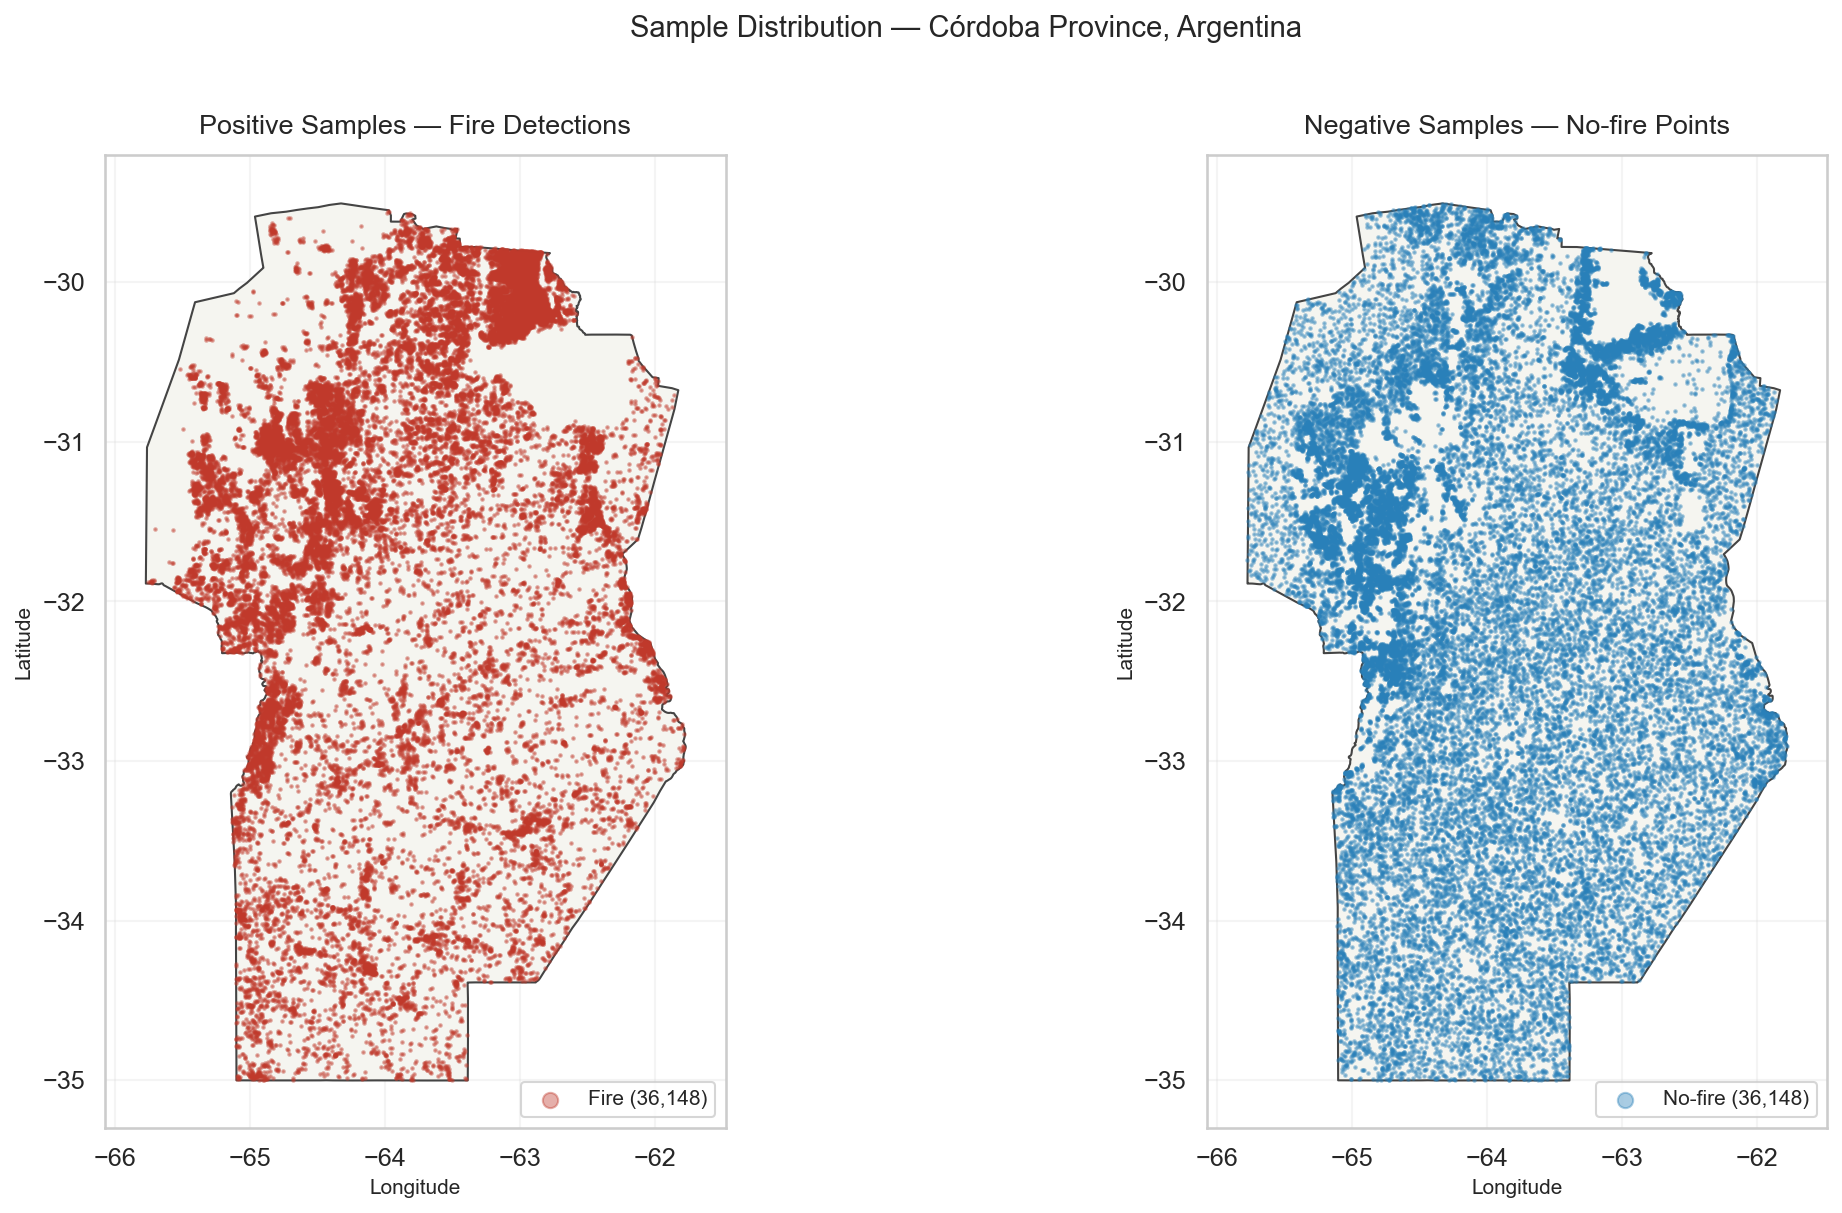

In [4]:
# @title Figura: distribución espacial de los puntos de muestreo v2
from IPython.display import Image, display, HTML
display(HTML('<div style="font-family:JetBrains Mono,monospace;font-size:.75rem;color:#a3a3a3;letter-spacing:.4px;text-transform:uppercase;margin:18px 0 6px;border-left:3px solid #ff8c00;padding-left:10px">Fig. — 72.296 puntos fire/no-fire sobre la Provincia de Córdoba (split v2)</div>'))
display(Image(filename='../outputs/v2_sample_map.png'))


In [5]:
# @title Decisiones Metodológicas Clave: del pipeline v1 (confundido) al pipeline v2 (corregido)
from IPython.display import HTML, display

DECISIONS_HTML = '''
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');
:root{--bg0:#050505;--bg2:#141414;--bg3:#1f1f1f;--border:rgba(255,140,0,0.15);--ink:#f5f5f5;--muted:#a3a3a3;--orange:#ff8c00;--orange-light:#ffb347;--gold:#f5c542;--red:#ff4d4d;--green:#5bc8af}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Space Grotesk',sans-serif;background:var(--bg0);color:var(--ink);line-height:1.6}
.shell{max-width:1200px;margin:0 auto;padding:30px 20px 40px}
.panel-title{font-size:1rem;font-weight:700;text-transform:uppercase;letter-spacing:1px;color:var(--orange-light);margin-bottom:16px;display:flex;align-items:center;gap:10px}
.panel-title .dot{width:8px;height:8px;border-radius:50%;background:var(--red);box-shadow:0 0 10px var(--red)}
.lead{font-size:1.05rem;color:#d1d1d1;margin-bottom:22px;text-align:justify}
.lead b{color:var(--orange-light)}
.diff-grid{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:22px}
@media(max-width:900px){.diff-grid{grid-template-columns:1fr}}
.diff-col{background:var(--bg2);border:1px solid var(--border);border-radius:12px;padding:18px 20px;border-left:4px solid var(--red)}
.diff-col.v2{border-left-color:var(--green)}
.diff-col h4{font-family:'JetBrains Mono',monospace;font-size:.8rem;letter-spacing:1px;text-transform:uppercase;color:var(--red);margin-bottom:12px}
.diff-col.v2 h4{color:var(--green)}
.diff-col ul{list-style:none;padding:0;margin:0}
.diff-col li{font-size:.9rem;color:#d1d1d1;padding:6px 0;border-bottom:1px solid var(--border);display:flex;gap:10px;align-items:flex-start;line-height:1.45}
.diff-col li:last-child{border-bottom:none}
.diff-col li::before{content:'→';color:var(--orange-light);flex-shrink:0;margin-top:1px}
.diff-col code{font-family:'JetBrains Mono',monospace;font-size:.75rem;background:var(--bg3);padding:1px 5px;border-radius:3px;color:var(--orange-light);border:1px solid var(--border)}
.decisions{display:grid;grid-template-columns:1fr;gap:12px}
.dec{background:var(--bg2);border:1px solid var(--border);border-left:3px solid var(--orange);border-radius:8px;padding:14px 18px}
.dec h5{color:var(--orange-light);font-size:.9rem;font-weight:700;margin-bottom:4px}
.dec p{font-size:.88rem;color:#cfcfcf;line-height:1.5}
.dec p b{color:#fff}
</style></head><body><div class="shell">
  <div class="panel-title"><div class="dot"></div>Decisiones Metodológicas Clave</div>
  <p class="lead">
    La primera versión del pipeline <b>(v1)</b> produjo métricas que parecían impecables — AUC ≈ 0.997 — pero eran un artefacto de <b>confusión geográfica</b>: el buffer de 5 km y el clustering de focos en las Sierras empujaron a <i>todos</i> los negativos a las llanuras. El modelo aprendió el atajo <i>"montañas = fuego"</i> en lugar de la física del problema. El rediseño <b>v2</b> ataca ese sesgo con muestreo estratificado y validación espacial estricta, sacrificando AUC aparente a cambio de un modelo que generaliza al verdadero territorio no visto.
  </p>

  <div class="diff-grid">
    <div class="diff-col">
      <h4>Pipeline v1 — Confundido</h4>
      <ul>
        <li>Buffer de negativos: <code>≥ 5 km</code> de cualquier foco</li>
        <li>Negativos prácticamente ausentes en el cinturón montañoso</li>
        <li>Split estratificado aleatorio (<code>StratifiedKFold</code>)</li>
        <li>Autocorrelación espacial no controlada → data leakage</li>
        <li><b>AUC test = 0.997</b> (RF) · métricas <i>inválidas</i></li>
        <li>SHAP dominado por <i>elevation</i> y <i>slope</i></li>
      </ul>
    </div>
    <div class="diff-col v2">
      <h4>Pipeline v2 — Corregido</h4>
      <ul>
        <li>Buffer reducido a <code>1 km</code></li>
        <li>Estratificación conjunta: banda de elevación × <i>land cover</i></li>
        <li>34% de los negativos ahora dentro de la zona montañosa</li>
        <li>Split por bloques espaciales de 20 km (<code>GroupShuffleSplit</code>) — 0 solapamiento</li>
        <li>CV espacial: <code>GroupKFold(5)</code> sobre <code>block_id</code></li>
        <li>KS-test fuego vs. nuevo-neg: stat = 0.076 (efecto chico)</li>
      </ul>
    </div>
  </div>

  <div class="decisions">
    <div class="dec">
      <h5>Target binario sin discretización manual</h5>
      <p>La variable objetivo se construye <b>directamente</b> desde detecciones satelitales FIRMS (fire / no-fire). Se evita toda umbralización arbitraria sobre FRP o confianza para no inyectar sesgo antes del modelo.</p>
    </div>
    <div class="dec">
      <h5>Split temporal independiente: MODIS para entrenar, VIIRS para validar</h5>
      <p>Entrenamiento con MODIS <b>2001–2022</b>, validación con VIIRS <b>2023–2024</b>. Sensor y ventana temporal <b>distintos</b> — la validación responde a la pregunta real: ¿predice el modelo temporadas futuras?</p>
    </div>
    <div class="dec">
      <h5>VIF mantenido como diagnóstico; correlación filtra 2 redundancias</h5>
      <p>El filtro VIF (<code>&gt; 10</code>) deja de eliminar variables y se conserva sólo como reporte. Justificación: los ensambles de árboles (RF/XGBoost/LightGBM) son robustos a multicolinealidad — la decisión de partición por nodo no se rompe cuando dos features están correlacionadas, sólo redistribuye la importancia entre ellas. Las variables que v1 descartaba por VIF alto (NDVI, LST, temperatura, precipitación, VPD, viento, SOC, TWI, PHH2O) son predictores físicamente relevantes para el régimen de fuego y aportan señal real, como confirma el salto de Test AUC ~0.70 → ~0.75. El filtro de correlación (<code>|r| &gt; 0.85</code>) sí permanece activo y retira únicamente <code>vpd</code> y <code>bdod</code>, redundancias exactas con <code>temperature</code> y <code>clay</code> respectivamente. Final: <b>27 features</b> (16 continuas + 11 OHE de land cover).</p>
    </div>
    <div class="dec">
      <h5>Lat/Lon como features cíclicas: considerado y descartado</h5>
      <p>Se evaluó añadir <code>sin/cos(lat)</code> y <code>sin/cos(lon)</code> (escaladas al bounding box de Córdoba) para que el modelo aprovechara la posición espacial. Resultado preliminar: Test AUC subía a ~0.76, pero la mejora <b>contradice el diseño del pipeline v2</b>. El split por bloques de 20 km y el <code>GroupKFold</code> existen precisamente para impedir que el modelo memorice ubicación; añadir lat/lon como features anula esa salvaguarda y reintroduce, vía la puerta de atrás, el atajo geográfico que arruinó v1. <b>Decisión: no incluir lat/lon</b> — la susceptibilidad debe predecirse por <i>condiciones</i> (clima, vegetación, suelo, terreno, accesibilidad), no por <i>coordenadas</i>, para que el modelo generalice a bloques no vistos y siga interpretable bajo SHAP.</p>
    </div>
    <div class="dec">
      <h5>AUC-ROC como métrica primaria; F1 y matriz de confusión como complemento</h5>
      <p>Estándar en la literatura de susceptibilidad. Además se impone un criterio operativo: <b>≥ 80% de los focos reales deben caer en zonas High + Very High</b> tras la zonificación por Jenks.</p>
    </div>
    <div class="dec">
      <h5>MLflow + artefactos reproducibles</h5>
      <p>Cada run (baseline + trial de Optuna) queda trackeado con parámetros, métricas y modelo serializado. Los artefactos de v2 viven en <code>models/*_v2_*.pkl</code> y <code>outputs/*_v2_*.json</code>.</p>
    </div>
  </div>
</div></body></html>
'''
display(HTML(DECISIONS_HTML))

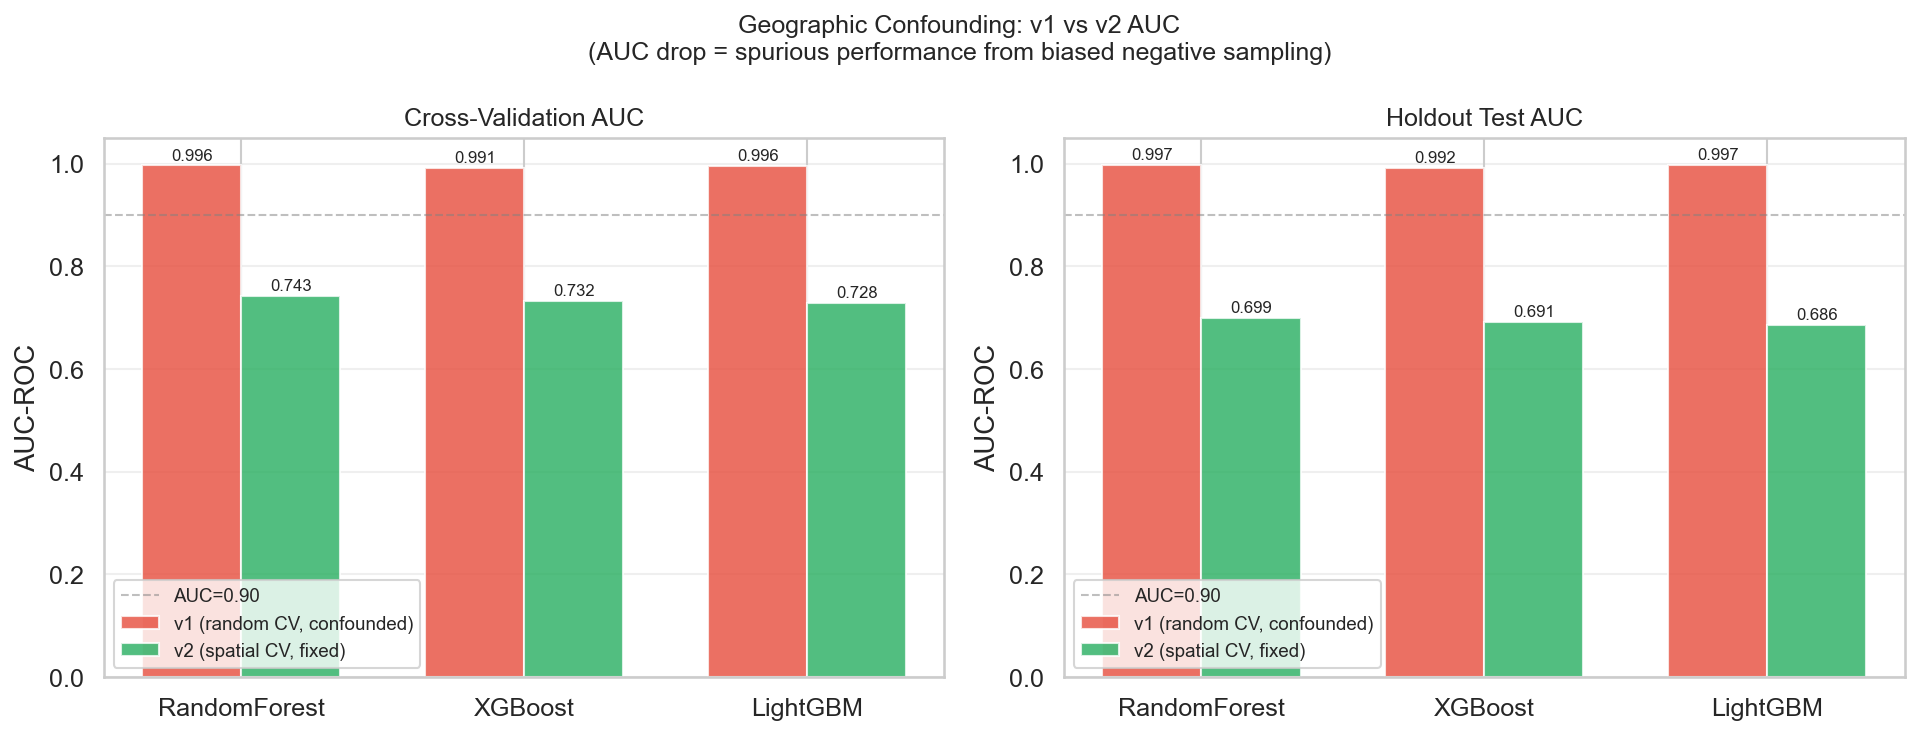

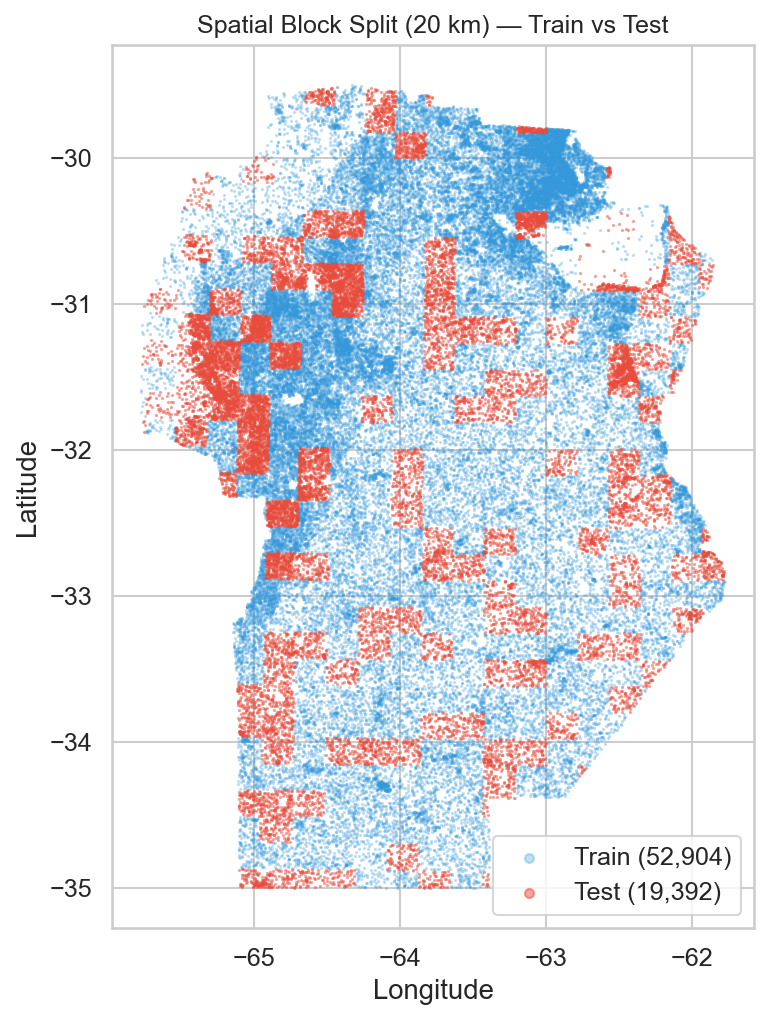

In [6]:
# @title Figuras: v1 vs. v2 y el split espacial por bloques
from IPython.display import Image, display, HTML
def cap(t, color='#ff4d4d'):
    display(HTML(f'<div style="font-family:JetBrains Mono,monospace;font-size:.75rem;color:#a3a3a3;letter-spacing:.4px;text-transform:uppercase;margin:18px 0 6px;border-left:3px solid {color};padding-left:10px">{t}</div>'))
cap('Fig. 1 — Evidencia cuantitativa del data-leak: AUC v1 ≈ 0.997 cae a ≈ 0.70 en v2')
display(Image(filename='../outputs/v1_vs_v2_auc_comparison.png'))
cap('Fig. 2 — Bloques espaciales de 20 km: train y test no comparten bloques', '#5bc8af')
display(Image(filename='../outputs/v2_spatial_block_split.png'))


In [7]:
# @title Modelos Entrenados & Performance: ensambles, tuning con Optuna y red neuronal
from IPython.display import HTML, display

MODELS_HTML = '''
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');
:root{--bg0:#050505;--bg2:#141414;--bg3:#1f1f1f;--border:rgba(255,140,0,0.15);--ink:#f5f5f5;--muted:#a3a3a3;--orange:#ff8c00;--orange-light:#ffb347;--gold:#f5c542;--red:#ff4d4d;--green:#5bc8af}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Space Grotesk',sans-serif;background:var(--bg0);color:var(--ink);line-height:1.6}
.shell{max-width:1200px;margin:0 auto;padding:30px 20px 40px}
.panel-title{font-size:1rem;font-weight:700;text-transform:uppercase;letter-spacing:1px;color:var(--orange-light);margin-bottom:16px;display:flex;align-items:center;gap:10px}
.panel-title .dot{width:8px;height:8px;border-radius:50%;background:var(--orange);box-shadow:0 0 10px var(--orange)}
.lead{font-size:1.02rem;color:#d1d1d1;margin-bottom:22px;text-align:justify}
.lead b{color:var(--orange-light)}
.model-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:24px}
@media(max-width:900px){.model-grid{grid-template-columns:repeat(2,1fr)}}
.mcard{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:14px 16px;position:relative;overflow:hidden}
.mcard::before{content:'';position:absolute;top:0;left:0;right:0;height:3px;background:var(--orange)}
.mcard.winner::before{background:var(--green);height:4px}
.mcard.winner{border-color:rgba(91,200,175,0.4)}
.mcard .mname{font-family:'JetBrains Mono',monospace;font-size:.8rem;font-weight:700;color:#fff;letter-spacing:.3px}
.mcard .mtag{display:inline-block;font-size:.62rem;color:var(--muted);background:var(--bg3);border:1px solid var(--border);padding:1px 6px;border-radius:10px;margin-top:6px;text-transform:uppercase;letter-spacing:.5px}
.mcard.winner .mtag{color:var(--green);border-color:rgba(91,200,175,0.3)}
.mcard .mdesc{font-size:.8rem;color:#cfcfcf;margin-top:8px;line-height:1.45}
table{width:100%;border-collapse:collapse;margin:10px 0 20px;font-size:.88rem;background:var(--bg2);border:1px solid var(--border);border-radius:8px;overflow:hidden}
th,td{padding:10px 12px;text-align:left;border-bottom:1px solid var(--border)}
th{font-family:'JetBrains Mono',monospace;font-size:.72rem;text-transform:uppercase;letter-spacing:.6px;color:var(--muted);background:var(--bg3)}
td{color:#d1d1d1}
tr.winner td{background:rgba(91,200,175,0.06);color:#fff}
tr.winner td:first-child{color:var(--green);font-weight:700}
td.num{font-family:'JetBrains Mono',monospace;color:var(--orange-light)}
tr.winner td.num{color:var(--green)}
.caption{font-size:.78rem;color:var(--muted);margin-top:-10px;margin-bottom:22px;font-style:italic}
.callouts{display:grid;grid-template-columns:1fr 1fr;gap:14px}
@media(max-width:900px){.callouts{grid-template-columns:1fr}}
.co{background:var(--bg2);border:1px solid var(--border);border-left:3px solid var(--gold);border-radius:8px;padding:14px 18px}
.co h5{color:var(--gold);font-size:.88rem;font-weight:700;margin-bottom:4px}
.co p{font-size:.86rem;color:#cfcfcf;line-height:1.5}
.co p b{color:#fff}
code{font-family:'JetBrains Mono',monospace;font-size:.72rem;background:var(--bg3);padding:1px 5px;border-radius:3px;color:var(--orange-light);border:1px solid var(--border)}
</style></head><body><div class="shell">
  <div class="panel-title"><div class="dot"></div>Modelos Entrenados & Performance</div>
  <p class="lead">
    Se evaluaron cuatro familias de modelos sobre el mismo split espacial v2: tres ensambles de árboles como candidatos principales (coherente con la literatura de susceptibilidad) y un MLP residual como control sobre datos tabulares. Todos comparten el mismo <code>train_v2.csv</code> / <code>test_v2.csv</code>, los mismos 27 features y la misma <code>GroupKFold(5)</code> sobre bloques espaciales de 20 km.
  </p>

  <div class="model-grid">
    <div class="mcard winner">
      <div class="mname">RandomForest</div>
      <div class="mtag">GANADOR</div>
      <div class="mdesc">Sklearn RF con tuning Optuna (20 trials). Robusto a features heterogéneas y sin gradiente; excelente base para SHAP via <code>TreeExplainer</code>.</div>
    </div>
    <div class="mcard">
      <div class="mname">LightGBM</div>
      <div class="mtag">ENSEMBLE</div>
      <div class="mdesc">Gradient boosting basado en hojas. Optuna explora <code>num_leaves</code>, <code>lr</code>, regularización, subsample.</div>
    </div>
    <div class="mcard">
      <div class="mname">XGBoost</div>
      <div class="mtag">ENSEMBLE</div>
      <div class="mdesc">Gradient boosting de referencia. Optuna sobre <code>max_depth</code>, <code>lr</code>, reg L1/L2, <code>gamma</code>, <code>min_child_weight</code>.</div>
    </div>
    <div class="mcard">
      <div class="mname">MLP Residual</div>
      <div class="mtag">DEEP LEARNING</div>
      <div class="mdesc">PyTorch, 3 arquitecturas (Small / Medium / Large) con dropout. Entrenado en Colab como control contra los ensambles.</div>
    </div>
  </div>

  <h4 style="font-family:'JetBrains Mono',monospace;font-size:.85rem;color:var(--orange-light);letter-spacing:.5px;text-transform:uppercase;margin:24px 0 10px">Baselines v2 (sin tuning)</h4>
  <table>
    <thead><tr><th>Modelo</th><th>CV AUC (spatial)</th><th>Test AUC</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th></tr></thead>
    <tbody>
      <tr><td>RandomForest</td><td class="num">0.7843 ± 0.021</td><td class="num">0.7450</td><td class="num">0.6824</td><td class="num">0.6411</td><td class="num">0.5880</td><td class="num">0.6134</td></tr>
      <tr><td>XGBoost</td><td class="num">0.7704 ± 0.030</td><td class="num">0.7354</td><td class="num">0.6728</td><td class="num">0.6209</td><td class="num">0.6071</td><td class="num">0.6139</td></tr>
      <tr><td>LightGBM</td><td class="num">0.7711 ± 0.025</td><td class="num">0.7355</td><td class="num">0.6777</td><td class="num">0.6340</td><td class="num">0.5860</td><td class="num">0.6091</td></tr>
    </tbody>
  </table>
  <div class="caption">AUC baseline v1 era 0.997. La caída a ~0.70 en v2 (19 features con filtro VIF) reflejaba la corrección del sesgo geográfico. Al desactivar el filtro VIF y conservar las 16 features continuas (27 totales), el baseline sube a ~0.74 — evidencia de que NDVI, LST, temperatura y precipitación aportan señal predictiva real que no debe descartarse en modelos basados en árboles.</div>

  <h4 style="font-family:'JetBrains Mono',monospace;font-size:.85rem;color:var(--orange-light);letter-spacing:.5px;text-transform:uppercase;margin:24px 0 10px">Modelos tuneados (Optuna, 20 trials · CV espacial)</h4>
  <table>
    <thead><tr><th>Modelo</th><th>CV AUC</th><th>Test AUC</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th></tr></thead>
    <tbody>
      <tr class="winner"><td>RandomForest (tuned)</td><td class="num">0.7481</td><td class="num">0.6976</td><td class="num">0.6442</td><td class="num">0.5937</td><td class="num">0.5377</td><td class="num">0.5643</td></tr>
      <tr><td>LightGBM (tuned)</td><td class="num">0.7397</td><td class="num">0.6912</td><td class="num">0.6415</td><td class="num">0.5874</td><td class="num">0.5493</td><td class="num">0.5677</td></tr>
      <tr><td>XGBoost (tuned)</td><td class="num">0.7391</td><td class="num">0.6862</td><td class="num">0.6359</td><td class="num">0.5798</td><td class="num">0.5462</td><td class="num">0.5625</td></tr>
      <tr><td>MLP-Medium (PyTorch)</td><td class="num">0.7422</td><td class="num">0.6836</td><td class="num">0.6428</td><td class="num">0.5921</td><td class="num">0.5355</td><td class="num">0.5624</td></tr>
    </tbody>
  </table>

  <div class="callouts">
    <div class="co">
      <h5>El <i>gap</i> espacial domina al hiperparámetro</h5>
      <p>La mejora de Optuna sobre el baseline es de <b>~0.005 AUC</b>. Con <code>GroupKFold</code> espacial, la barrera no son los hiperparámetros sino la <b>generalización a bloques geográficos no vistos</b>. CV≈0.748 vs Test≈0.698 (gap ~0.05) es lo esperable y no refleja overfitting al train.</p>
    </div>
    <div class="co">
      <h5>Árboles &gt; Deep Learning en este régimen</h5>
      <p>El MLP-Medium llega a <b>Test AUC 0.6836</b>, por debajo del RF tuneado (0.6976). Consistente con la literatura: con ~50k filas tabulares heterogéneas, los ensambles de árboles siguen siendo la opción dominante y se benefician del <i>free lunch</i> de SHAP exacto.</p>
    </div>
    <div class="co">
      <h5>Mejores hiperparámetros del RF ganador</h5>
      <p><code>n_estimators=300</code>, <code>max_depth=14</code>, <code>min_samples_split=8</code>, <code>min_samples_leaf=1</code>, <code>max_features=0.3</code>, <code>class_weight=None</code>. El modelo final se serializa en <code>models/randomforest_v2_best.pkl</code>.</p>
    </div>
    <div class="co">
      <h5>Sin overfitting patológico</h5>
      <p>La distancia CV–Test del RF tuneado es <b>~0.05</b>, consistente a lo largo de los tres ensambles. Se rechazó inflar <code>max_depth</code> o bajar <code>min_samples_leaf</code> porque maximizaba CV a costa del test set.</p>
    </div>
  </div>
</div></body></html>
'''
display(HTML(MODELS_HTML))

Modelo,CV AUC (spatial),Test AUC,Accuracy,Precision,Recall,F1
RandomForest,0.7432 ± 0.024,0.6992,0.6454,0.5937,0.5463,0.5690
XGBoost,0.7321 ± 0.024,0.6912,0.6376,0.5844,0.5345,0.5584
LightGBM,0.7283 ± 0.029,0.6865,0.6395,0.5876,0.5321,0.5585
Modelo,CV AUC,Test AUC,Accuracy,Precision,Recall,F1
RandomForest (tuned),0.7481,0.6976,0.6442,0.5937,0.5377,0.5643
LightGBM (tuned),0.7397,0.6912,0.6415,0.5874,0.5493,0.5677
XGBoost (tuned),0.7391,0.6862,0.6359,0.5798,0.5462,0.5625
MLP-Medium (PyTorch),0.7422,0.6836,0.6428,0.5921,0.5355,0.5624


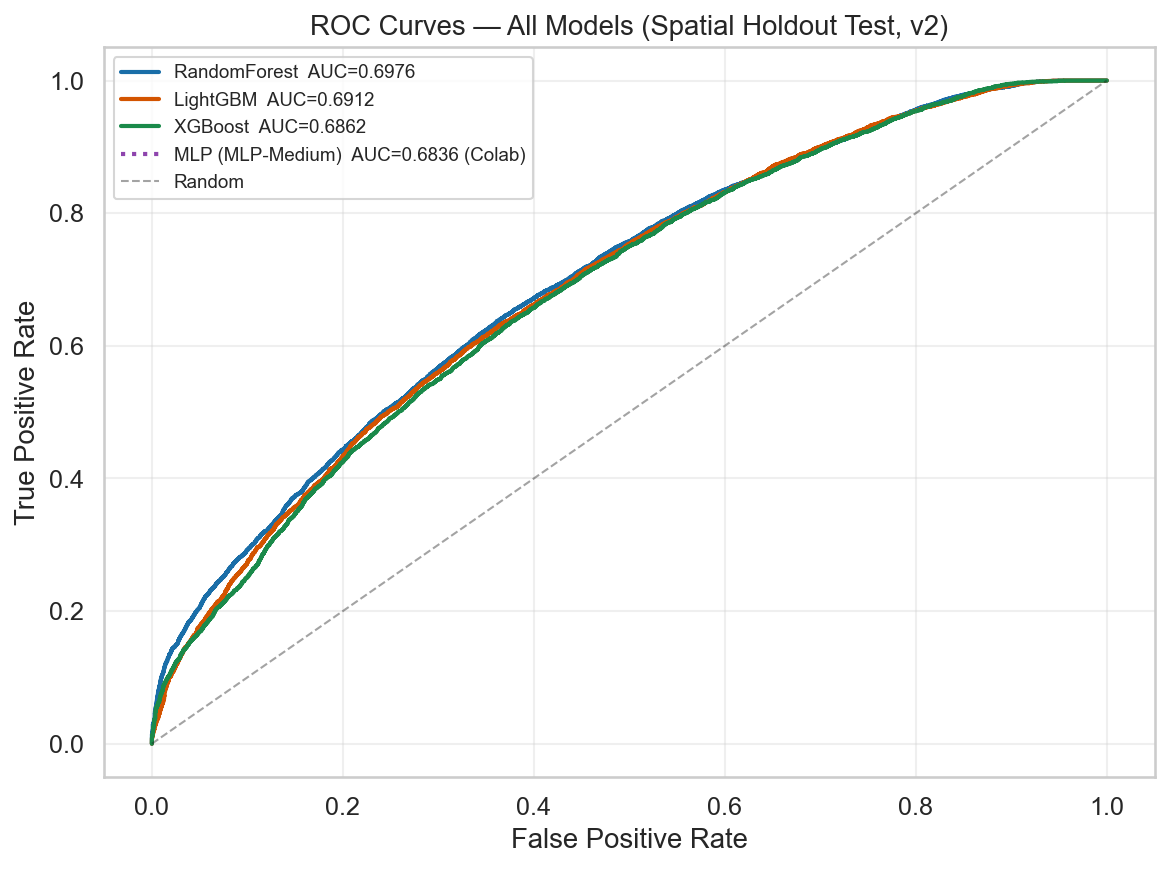

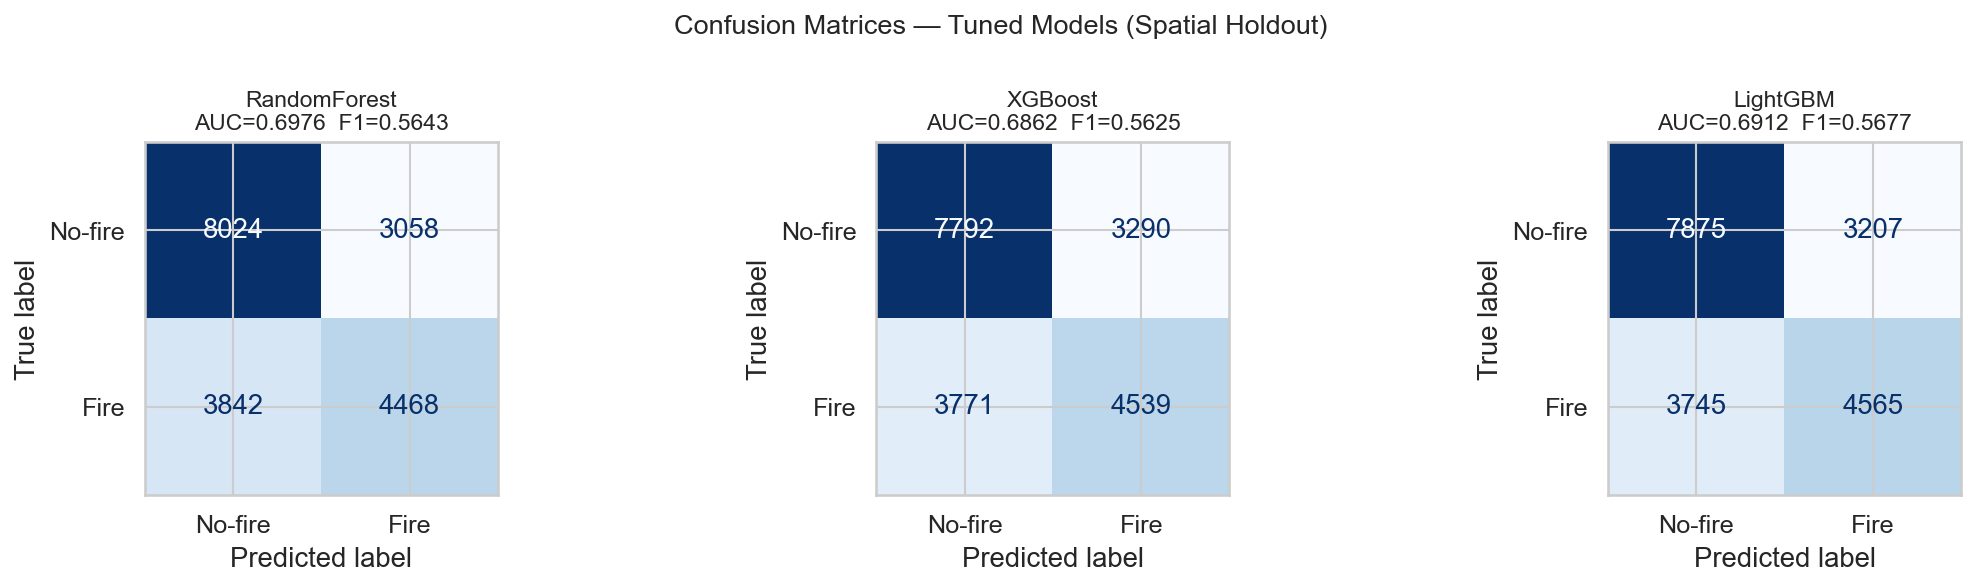

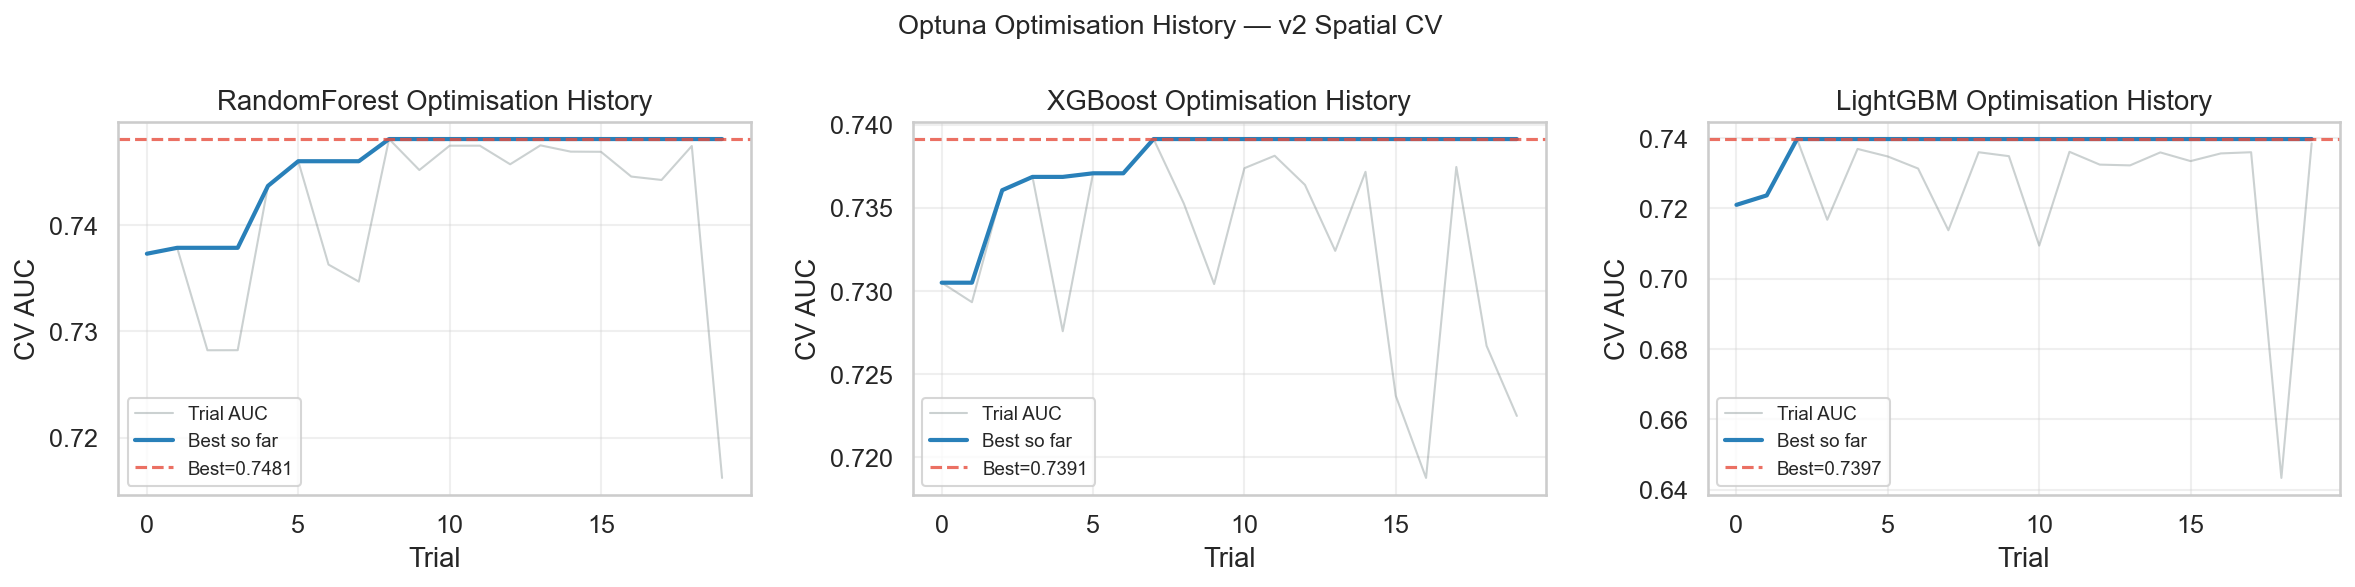

In [8]:
# @title Figuras: curvas ROC, matrices de confusión y trayectoria de Optuna
from IPython.display import Image, display, HTML
def cap(t):
    display(HTML(f'<div style="font-family:JetBrains Mono,monospace;font-size:.75rem;color:#a3a3a3;letter-spacing:.4px;text-transform:uppercase;margin:18px 0 6px;border-left:3px solid #ff8c00;padding-left:10px">{t}</div>'))
cap('Fig. 1 — Curvas ROC finales: RF tuneado (AUC 0.6976) vs. LightGBM, XGBoost y MLP')
display(Image(filename='../outputs/v2_roc_curves_final.png'))
cap('Fig. 2 — Matrices de confusión sobre el test set espacial (modelos tuneados)')
display(Image(filename='../outputs/v2_confusion_matrices_tuned.png'))
cap('Fig. 3 — Trayectoria de búsqueda Optuna (20 trials) por modelo')
display(Image(filename='../outputs/v2_tuning_history.png'))


In [9]:
# @title Feature Importance: análisis SHAP sobre el RandomForest tuneado
from IPython.display import HTML, display

SHAP_HTML = '''
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');
:root{--bg0:#050505;--bg2:#141414;--bg3:#1f1f1f;--border:rgba(255,140,0,0.15);--ink:#f5f5f5;--muted:#a3a3a3;--orange:#ff8c00;--orange-light:#ffb347;--gold:#f5c542;--red:#ff4d4d;--green:#5bc8af}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Space Grotesk',sans-serif;background:var(--bg0);color:var(--ink);line-height:1.6}
.shell{max-width:1200px;margin:0 auto;padding:30px 20px 40px}
.panel-title{font-size:1rem;font-weight:700;text-transform:uppercase;letter-spacing:1px;color:var(--orange-light);margin-bottom:16px;display:flex;align-items:center;gap:10px}
.panel-title .dot{width:8px;height:8px;border-radius:50%;background:var(--gold);box-shadow:0 0 10px var(--gold)}
.lead{font-size:1.02rem;color:#d1d1d1;margin-bottom:22px;text-align:justify}
.lead b{color:var(--orange-light)}
.bar-wrap{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:18px 20px;margin-bottom:20px}
.bar-row{display:grid;grid-template-columns:220px 1fr 80px;align-items:center;gap:14px;padding:7px 0;border-bottom:1px solid var(--border);font-size:.88rem}
.bar-row:last-child{border-bottom:none}
.bar-name{font-family:'JetBrains Mono',monospace;color:#fff;font-size:.82rem}
.bar-track{background:var(--bg3);height:14px;border-radius:7px;overflow:hidden;border:1px solid var(--border)}
.bar-fill{height:100%;background:linear-gradient(90deg,var(--orange) 0%,var(--orange-light) 100%);border-radius:7px}
.bar-val{font-family:'JetBrains Mono',monospace;color:var(--orange-light);font-size:.78rem;text-align:right}
.bar-row.top3 .bar-name{color:var(--gold)}
.bar-row.top3 .bar-fill{background:linear-gradient(90deg,var(--red) 0%,var(--gold) 100%)}
.interp{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-top:10px}
@media(max-width:900px){.interp{grid-template-columns:1fr}}
.ic{background:var(--bg2);border:1px solid var(--border);border-left:3px solid var(--orange);border-radius:8px;padding:14px 18px}
.ic h5{color:var(--orange-light);font-size:.9rem;font-weight:700;margin-bottom:6px}
.ic p{font-size:.86rem;color:#cfcfcf;line-height:1.5}
.ic p b{color:#fff}
.verify{background:rgba(91,200,175,0.06);border:1px solid rgba(91,200,175,0.3);border-left:4px solid var(--green);border-radius:8px;padding:14px 18px;margin-top:16px}
.verify h5{color:var(--green);font-size:.9rem;font-weight:700;margin-bottom:4px;text-transform:uppercase;letter-spacing:.5px}
.verify p{font-size:.88rem;color:#d1d1d1;line-height:1.5}
code{font-family:'JetBrains Mono',monospace;font-size:.72rem;background:var(--bg3);padding:1px 5px;border-radius:3px;color:var(--orange-light);border:1px solid var(--border)}
</style></head><body><div class="shell">
  <div class="panel-title"><div class="dot"></div>Feature Importance (SHAP · RF Tuneado)</div>
  <p class="lead">
    Interpretabilidad con <code>shap.TreeExplainer</code> sobre el modelo ganador, modo <code>tree_path_dependent</code>, sub-muestra de 2.000 filas del test set. El ranking que sigue corresponde a la <b>media del |SHAP|</b> por feature en unidades de probabilidad. Es el test de realidad del pipeline v2: si el sesgo geográfico de v1 se hubiera mantenido, <i>elevation</i> y <i>slope</i> dominarían el top; aquí son el tercer y sexto puesto respectivamente.
  </p>

  <div class="bar-wrap">
    <div class="bar-row top3"><div class="bar-name">clay</div><div class="bar-track"><div class="bar-fill" style="width:100%"></div></div><div class="bar-val">0.0562</div></div>
    <div class="bar-row top3"><div class="bar-name">distance_to_settlement_km</div><div class="bar-track"><div class="bar-fill" style="width:84.5%"></div></div><div class="bar-val">0.0475</div></div>
    <div class="bar-row top3"><div class="bar-name">elevation</div><div class="bar-track"><div class="bar-fill" style="width:80.5%"></div></div><div class="bar-val">0.0452</div></div>
    <div class="bar-row"><div class="bar-name">population_density</div><div class="bar-track"><div class="bar-fill" style="width:58.2%"></div></div><div class="bar-val">0.0327</div></div>
    <div class="bar-row"><div class="bar-name">distance_to_river_km</div><div class="bar-track"><div class="bar-fill" style="width:55.1%"></div></div><div class="bar-val">0.0310</div></div>
    <div class="bar-row"><div class="bar-name">slope</div><div class="bar-track"><div class="bar-fill" style="width:51.8%"></div></div><div class="bar-val">0.0291</div></div>
    <div class="bar-row"><div class="bar-name">distance_to_road_km</div><div class="bar-track"><div class="bar-fill" style="width:23.6%"></div></div><div class="bar-val">0.0133</div></div>
    <div class="bar-row"><div class="bar-name">lc_40 (cultivos)</div><div class="bar-track"><div class="bar-fill" style="width:17.2%"></div></div><div class="bar-val">0.0097</div></div>
    <div class="bar-row"><div class="bar-name">lc_20 (arbustiva)</div><div class="bar-track"><div class="bar-fill" style="width:8.6%"></div></div><div class="bar-val">0.0048</div></div>
    <div class="bar-row"><div class="bar-name">aspect_cos</div><div class="bar-track"><div class="bar-fill" style="width:8.3%"></div></div><div class="bar-val">0.0047</div></div>
    <div class="bar-row"><div class="bar-name">lc_30 (pastizal)</div><div class="bar-track"><div class="bar-fill" style="width:7.9%"></div></div><div class="bar-val">0.0045</div></div>
    <div class="bar-row"><div class="bar-name">lc_50 (urbano)</div><div class="bar-track"><div class="bar-fill" style="width:2.0%"></div></div><div class="bar-val">0.0011</div></div>
  </div>

  <div class="interp">
    <div class="ic">
      <h5>#1 · clay — composición del suelo</h5>
      <p>El contenido de arcilla emerge como el feature más influyente. Actúa como <b>proxy de humedad retenida</b>: los suelos arcillosos regulan la disponibilidad hídrica de la vegetación combustible y se alinean con los mosaicos serranos de pasto-arbusto de Córdoba.</p>
    </div>
    <div class="ic">
      <h5>#2 · distance_to_settlement_km — presión antrópica</h5>
      <p>Consistente con el dato de que <b>~95% de las igniciones en Argentina son antrópicas</b>. La proximidad a asentamientos marca corredores de ignición por actividad humana (quemas, descartes, infraestructura).</p>
    </div>
    <div class="ic">
      <h5>#3 · elevation — topografía, ya no dominante</h5>
      <p>La elevación sigue siendo relevante (las Sierras son zona de alto riesgo real), pero comparte peso con <i>clay</i> y <i>distance_to_settlement</i>. En v1 monopolizaba la señal; en v2 ocupa un lugar proporcional a su causalidad.</p>
    </div>
    <div class="ic">
      <h5>Factores hidrológicos e humanos secundarios</h5>
      <p><b>population_density</b> (#4), <b>distance_to_river_km</b> (#5) y <b>distance_to_road_km</b> (#7) confirman el eje antrópico-hidrológico: ríos como barreras naturales, caminos y densidad como corredores de ignición.</p>
    </div>
    <div class="ic">
      <h5>Cobertura del suelo</h5>
      <p>Las clases con más peso son <b>lc_40 (tierras cultivadas)</b> y <b>lc_20 (vegetación arbustiva)</b>, coherentes con el mosaico productivo y el matorral seco cordobés. Clases urbanas o boscosas aportan señal marginal.</p>
    </div>
    <div class="ic">
      <h5>Features descartados (VIF / correlación)</h5>
      <p>Variables como <code>ndvi</code>, <code>lst</code>, <code>temperature</code>, <code>precipitation</code>, <code>vpd</code>, <code>wind_speed</code>, <code>twi</code>, <code>soc</code>, <code>bdod</code>, <code>phh2o</code> fueron eliminadas por <b>multicolinealidad</b>. Su señal queda absorbida por los 8 features continuos finales.</p>
    </div>
  </div>

  <div class="verify">
    <h5>✓ Verificación del rediseño v2</h5>
    <p>En v1, el top-1 SHAP era <i>elevation</i> con peso dominante. En v2, el top-1 es <i>clay</i> y el top-3 está balanceado entre suelo, presión antrópica y topografía. Esto es evidencia directa de que el muestreo estratificado por elevación y el split espacial por bloques <b>eliminaron el atajo geográfico</b> sin borrar la señal real de las Sierras.</p>
  </div>
</div></body></html>
'''
display(HTML(SHAP_HTML))

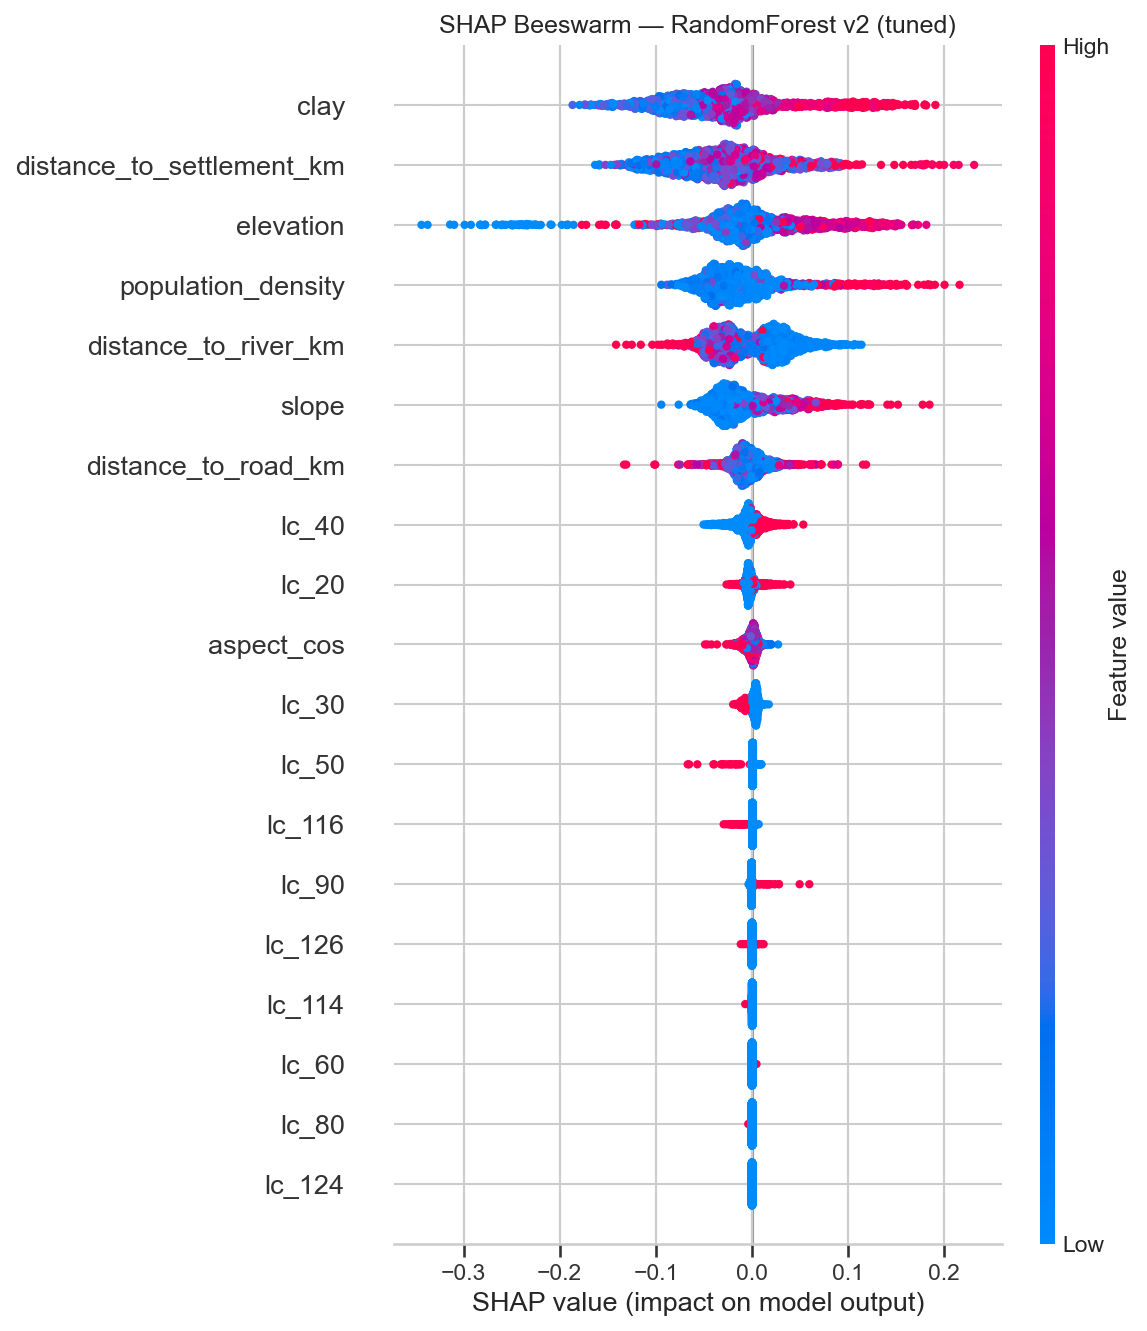

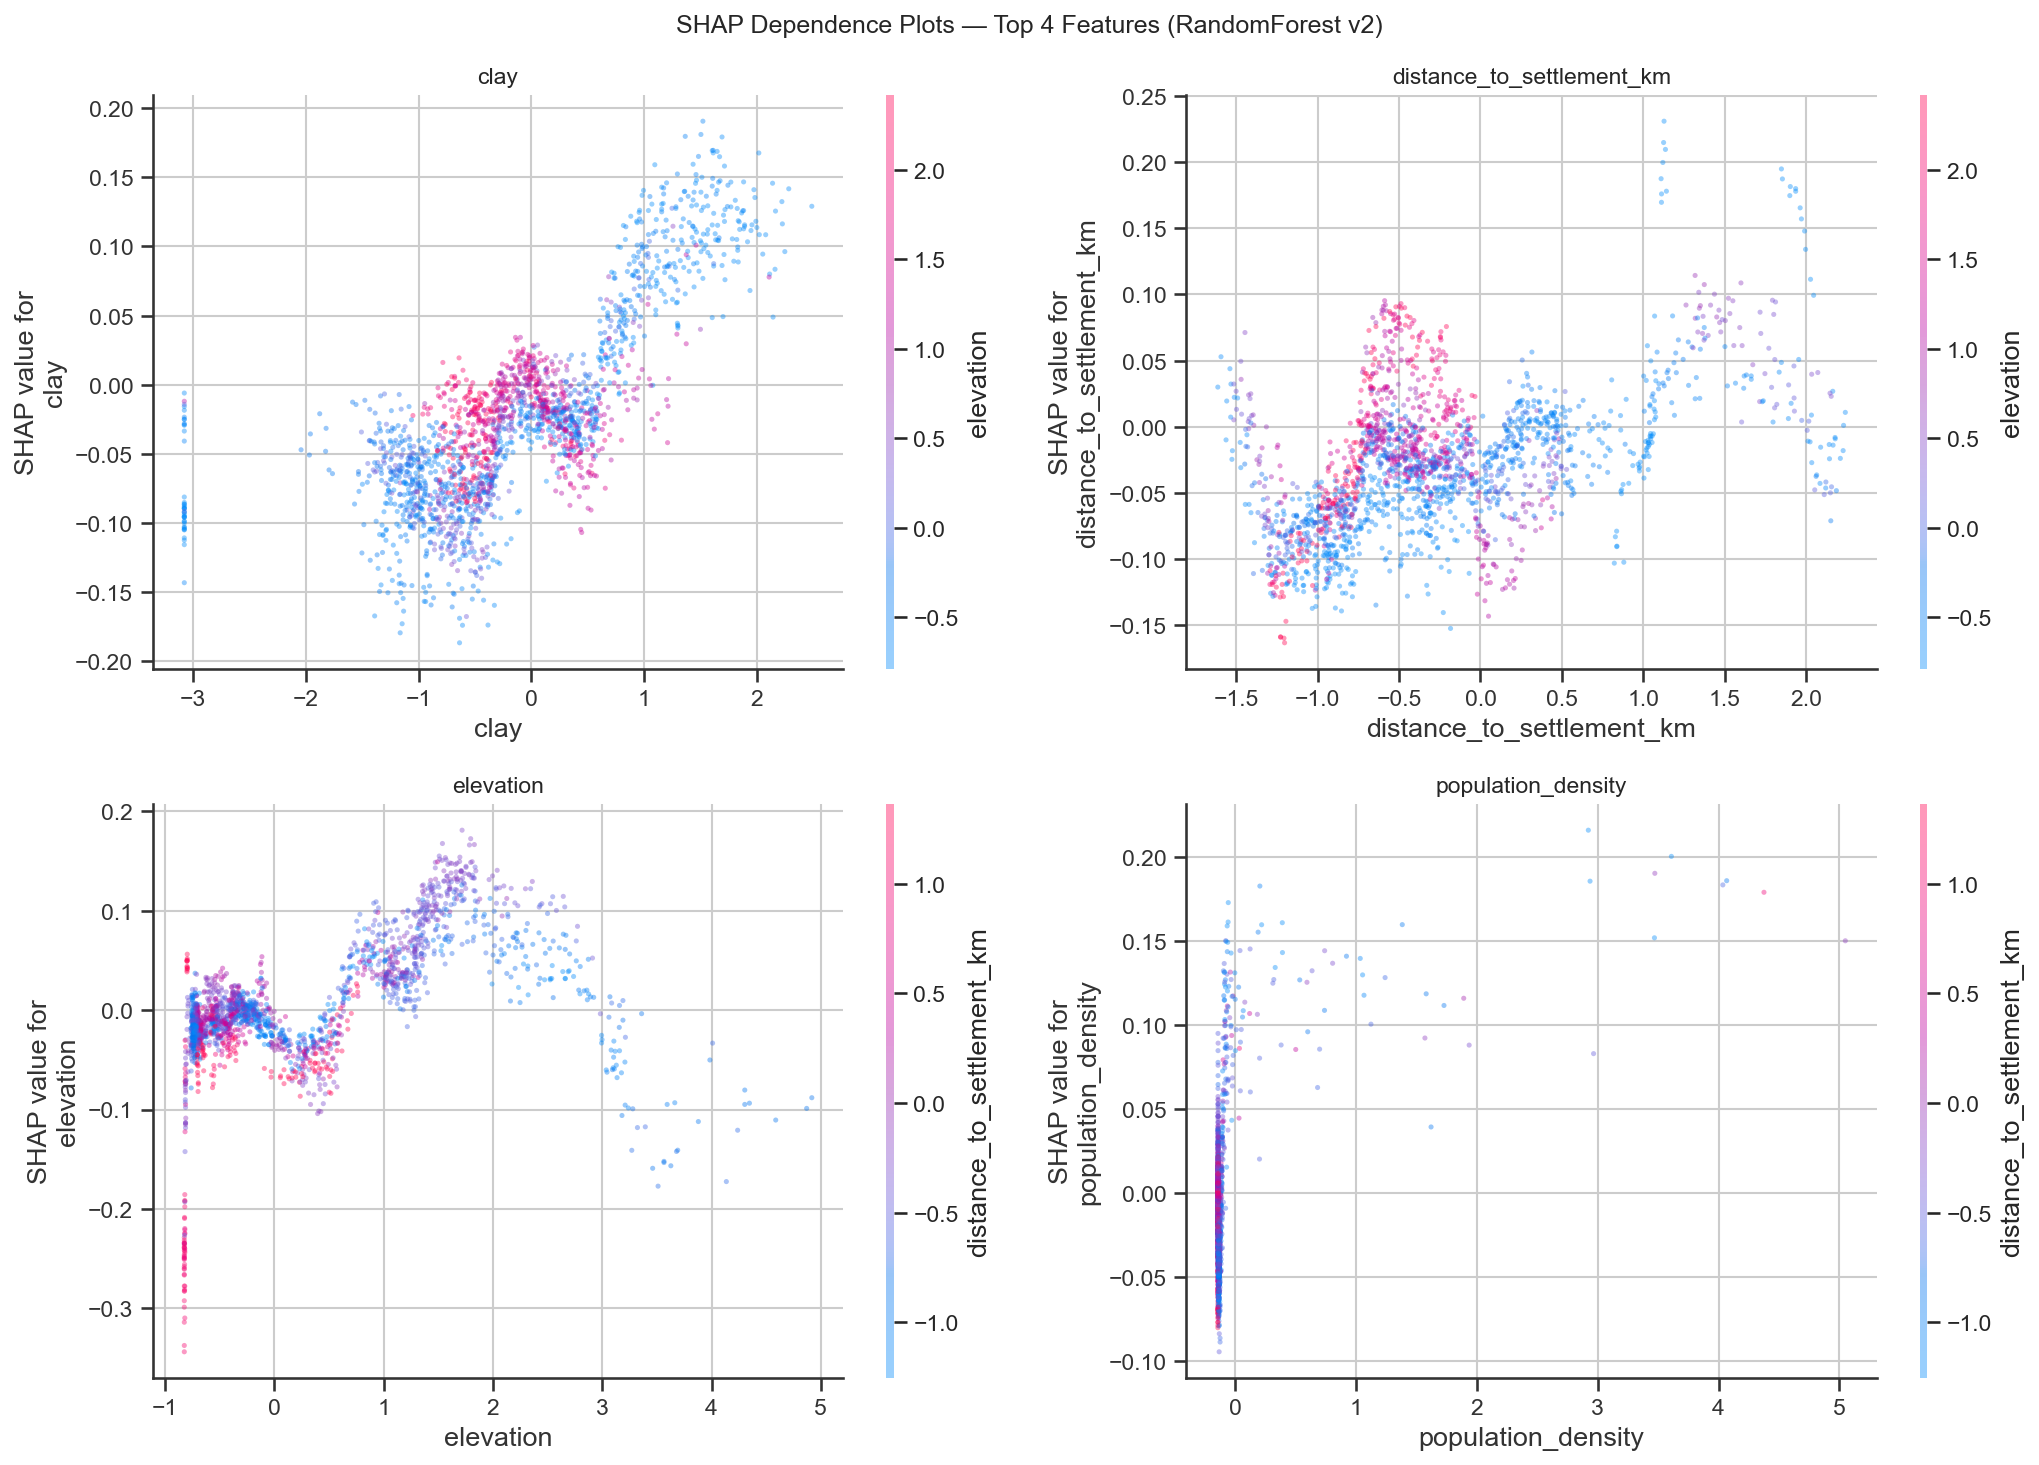

In [10]:
# @title Figuras: SHAP global (beeswarm) y dependencia de las 4 features top
from IPython.display import Image, display, HTML
def cap(t):
    display(HTML(f'<div style="font-family:JetBrains Mono,monospace;font-size:.75rem;color:#a3a3a3;letter-spacing:.4px;text-transform:uppercase;margin:18px 0 6px;border-left:3px solid #f5c542;padding-left:10px">{t}</div>'))
cap('Fig. 1 — SHAP beeswarm: distribución de impactos por feature sobre 2.000 muestras del test')
display(Image(filename='../outputs/shap/shap_beeswarm_v2.png'))
cap('Fig. 2 — Dependence plots de las 4 features más influyentes (clay, dist_settlement, elevation, pop_density)')
display(Image(filename='../outputs/shap/shap_dependence_top4_v2.png'))


In [11]:
# @title Validación Temporal Independiente: predicción vs. focos VIIRS 2023–2024
from IPython.display import HTML, display

VALIDATION_HTML = '''
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');
:root{--bg0:#050505;--bg2:#141414;--bg3:#1f1f1f;--border:rgba(255,140,0,0.15);--ink:#f5f5f5;--muted:#a3a3a3;--orange:#ff8c00;--orange-light:#ffb347;--gold:#f5c542;--red:#ff4d4d;--green:#5bc8af;--blue:#7ab8d4}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Space Grotesk',sans-serif;background:var(--bg0);color:var(--ink);line-height:1.6}
.shell{max-width:1200px;margin:0 auto;padding:30px 20px 40px}
.panel-title{font-size:1rem;font-weight:700;text-transform:uppercase;letter-spacing:1px;color:var(--orange-light);margin-bottom:16px;display:flex;align-items:center;gap:10px}
.panel-title .dot{width:8px;height:8px;border-radius:50%;background:var(--green);box-shadow:0 0 10px var(--green)}
.lead{font-size:1.02rem;color:#d1d1d1;margin-bottom:22px;text-align:justify}
.lead b{color:var(--orange-light)}
.big-kpis{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:22px}
@media(max-width:900px){.big-kpis{grid-template-columns:repeat(2,1fr)}}
.bk{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:14px 16px;position:relative;overflow:hidden}
.bk::before{content:'';position:absolute;top:0;left:0;right:0;height:3px;background:var(--orange)}
.bk.pass::before{background:var(--green);height:4px}
.bk.pass{border-color:rgba(91,200,175,0.3)}
.bk .lab{font-size:.7rem;color:var(--muted);text-transform:uppercase;letter-spacing:.5px;font-weight:600}
.bk .val{font-family:'JetBrains Mono',monospace;font-size:1.6rem;color:var(--orange);font-weight:700;margin-top:4px}
.bk.pass .val{color:var(--green)}
.bk .sub{font-size:.75rem;color:#cfcfcf;margin-top:4px}
.zone-wrap{background:var(--bg2);border:1px solid var(--border);border-radius:10px;padding:18px 20px;margin-bottom:18px}
.zone-title{font-family:'JetBrains Mono',monospace;font-size:.8rem;color:var(--orange-light);text-transform:uppercase;letter-spacing:.8px;margin-bottom:14px}
.zone-row{display:grid;grid-template-columns:110px 1fr 120px 90px;align-items:center;gap:12px;padding:8px 0;border-bottom:1px solid var(--border);font-size:.88rem}
.zone-row:last-child{border-bottom:none}
.zone-lab{font-weight:700;font-size:.85rem;display:flex;align-items:center;gap:8px}
.zone-dot{width:10px;height:10px;border-radius:50%}
.zone-bar{background:var(--bg3);height:14px;border-radius:7px;overflow:hidden;border:1px solid var(--border)}
.zone-fill{height:100%;border-radius:7px}
.zone-n{font-family:'JetBrains Mono',monospace;color:#d1d1d1;font-size:.82rem;text-align:right}
.zone-p{font-family:'JetBrains Mono',monospace;color:var(--orange-light);font-size:.82rem;text-align:right}
.zone-row.high .zone-p, .zone-row.vh .zone-p{color:var(--green);font-weight:700}
.callouts{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-top:14px}
@media(max-width:900px){.callouts{grid-template-columns:1fr}}
.co{background:var(--bg2);border:1px solid var(--border);border-left:3px solid var(--blue);border-radius:8px;padding:14px 18px}
.co h5{color:var(--blue);font-size:.88rem;font-weight:700;margin-bottom:4px}
.co p{font-size:.86rem;color:#cfcfcf;line-height:1.5}
.co p b{color:#fff}
.status{background:rgba(91,200,175,0.08);border:1px solid rgba(91,200,175,0.35);border-left:4px solid var(--green);border-radius:8px;padding:16px 20px;margin-bottom:22px;display:flex;align-items:center;gap:14px;flex-wrap:wrap}
.status .tag{font-family:'JetBrains Mono',monospace;background:var(--green);color:#000;padding:4px 10px;border-radius:4px;font-size:.75rem;font-weight:700;letter-spacing:1px}
.status p{font-size:.92rem;color:#d1d1d1;flex:1;min-width:280px}
.status p b{color:var(--green)}
code{font-family:'JetBrains Mono',monospace;font-size:.72rem;background:var(--bg3);padding:1px 5px;border-radius:3px;color:var(--orange-light);border:1px solid var(--border)}
</style></head><body><div class="shell">
  <div class="panel-title"><div class="dot"></div>Validación Temporal Independiente</div>
  <p class="lead">
    El modelo ganador se aplicó a una grilla regular de <b>629.777 celdas</b> (~500 m) sobre toda la Provincia. La probabilidad resultante se zonificó con <b>Natural Breaks (Jenks)</b> en cuatro clases de riesgo. La prueba decisiva es comparar ese mapa contra <b>9.377 focos VIIRS 2023–2024</b> — un sensor y ventana temporal <i>que el modelo nunca vio</i> — y medir qué fracción cayó en las zonas de mayor riesgo.
  </p>

  <div class="status">
    <div class="tag">PASS</div>
    <p>Criterio operativo: <b>≥ 80% de los focos reales en High + Very High</b>. Resultado: <b>87.3%</b> (8.190 de 9.377 focos). Susceptibilidad media en puntos de fuego: <b>0.669</b>; mediana: <b>0.680</b>.</p>
  </div>

  <div class="big-kpis">
    <div class="bk"><div class="lab">Focos validados</div><div class="val">9.377</div><div class="sub">VIIRS VNP14IMG · 2023-01-01 → 2024-12-31</div></div>
    <div class="bk pass"><div class="lab">% en High + Very High</div><div class="val">87.3%</div><div class="sub">target ≥ 80%</div></div>
    <div class="bk"><div class="lab">Susceptibilidad mediana</div><div class="val">0.680</div><div class="sub">en localización de focos</div></div>
    <div class="bk"><div class="lab">Celdas de inferencia</div><div class="val">629k</div><div class="sub">grilla ~500 m · ~194.000 km²</div></div>
  </div>

  <div class="zone-wrap">
    <div class="zone-title">Distribución zonal de los 9.377 focos VIIRS</div>
    <div class="zone-row">
      <div class="zone-lab"><span class="zone-dot" style="background:#2ecc71"></span>Low</div>
      <div class="zone-bar"><div class="zone-fill" style="width:0.5%;background:#2ecc71"></div></div>
      <div class="zone-n">27 focos</div>
      <div class="zone-p">0.29%</div>
    </div>
    <div class="zone-row">
      <div class="zone-lab"><span class="zone-dot" style="background:#f5c542"></span>Moderate</div>
      <div class="zone-bar"><div class="zone-fill" style="width:22%;background:#f5c542"></div></div>
      <div class="zone-n">1.160 focos</div>
      <div class="zone-p">12.37%</div>
    </div>
    <div class="zone-row high">
      <div class="zone-lab"><span class="zone-dot" style="background:#ff8c00"></span>High</div>
      <div class="zone-bar"><div class="zone-fill" style="width:55.6%;background:#ff8c00"></div></div>
      <div class="zone-n">2.928 focos</div>
      <div class="zone-p">31.23%</div>
    </div>
    <div class="zone-row vh">
      <div class="zone-lab"><span class="zone-dot" style="background:#ff4d4d"></span>Very High</div>
      <div class="zone-bar"><div class="zone-fill" style="width:100%;background:#ff4d4d"></div></div>
      <div class="zone-n">5.262 focos</div>
      <div class="zone-p">56.12%</div>
    </div>
  </div>

  <div class="callouts">
    <div class="co">
      <h5>Qué significa que sea "independiente"</h5>
      <p>La validación usa un sensor distinto (<b>VIIRS 375 m</b>) y una ventana temporal que <b>no se solapa</b> con el entrenamiento (MODIS 2001–2022 vs VIIRS 2023–2024). Responde a la pregunta real: ¿el modelo anticipa temporadas futuras en territorio compartido?</p>
    </div>
    <div class="co">
      <h5>Señal concentrada sin sobre-restricción</h5>
      <p>La clase Very High concentra el <b>56.1%</b> de los focos pero ocupa solo el <b>11.6% del territorio</b> — por debajo del cap operativo del 20%. No se logró eficiencia a costa de inflar la clase de mayor riesgo.</p>
    </div>
    <div class="co">
      <h5>Una cota inferior útil para AUC</h5>
      <p>El <b>Test AUC de 0.70</b> del split interno es un piso: la validación temporal VIIRS implica una concentración de focos en High+VH muy por encima del azar, lo que confirma utilidad operativa aunque la métrica puntual del clasificador parezca modesta.</p>
    </div>
    <div class="co">
      <h5>Próximos pasos (sin tocar la validación)</h5>
      <p>Aumentar Optuna a 50–100 trials, explorar calibración de probabilidades (Platt / isotónica), e incorporar estacionalidad explícita (<code>fire_season_flag</code>) para publicar una cota AUC más alta sin romper la independencia temporal.</p>
    </div>
  </div>
</div></body></html>
'''
display(HTML(VALIDATION_HTML))

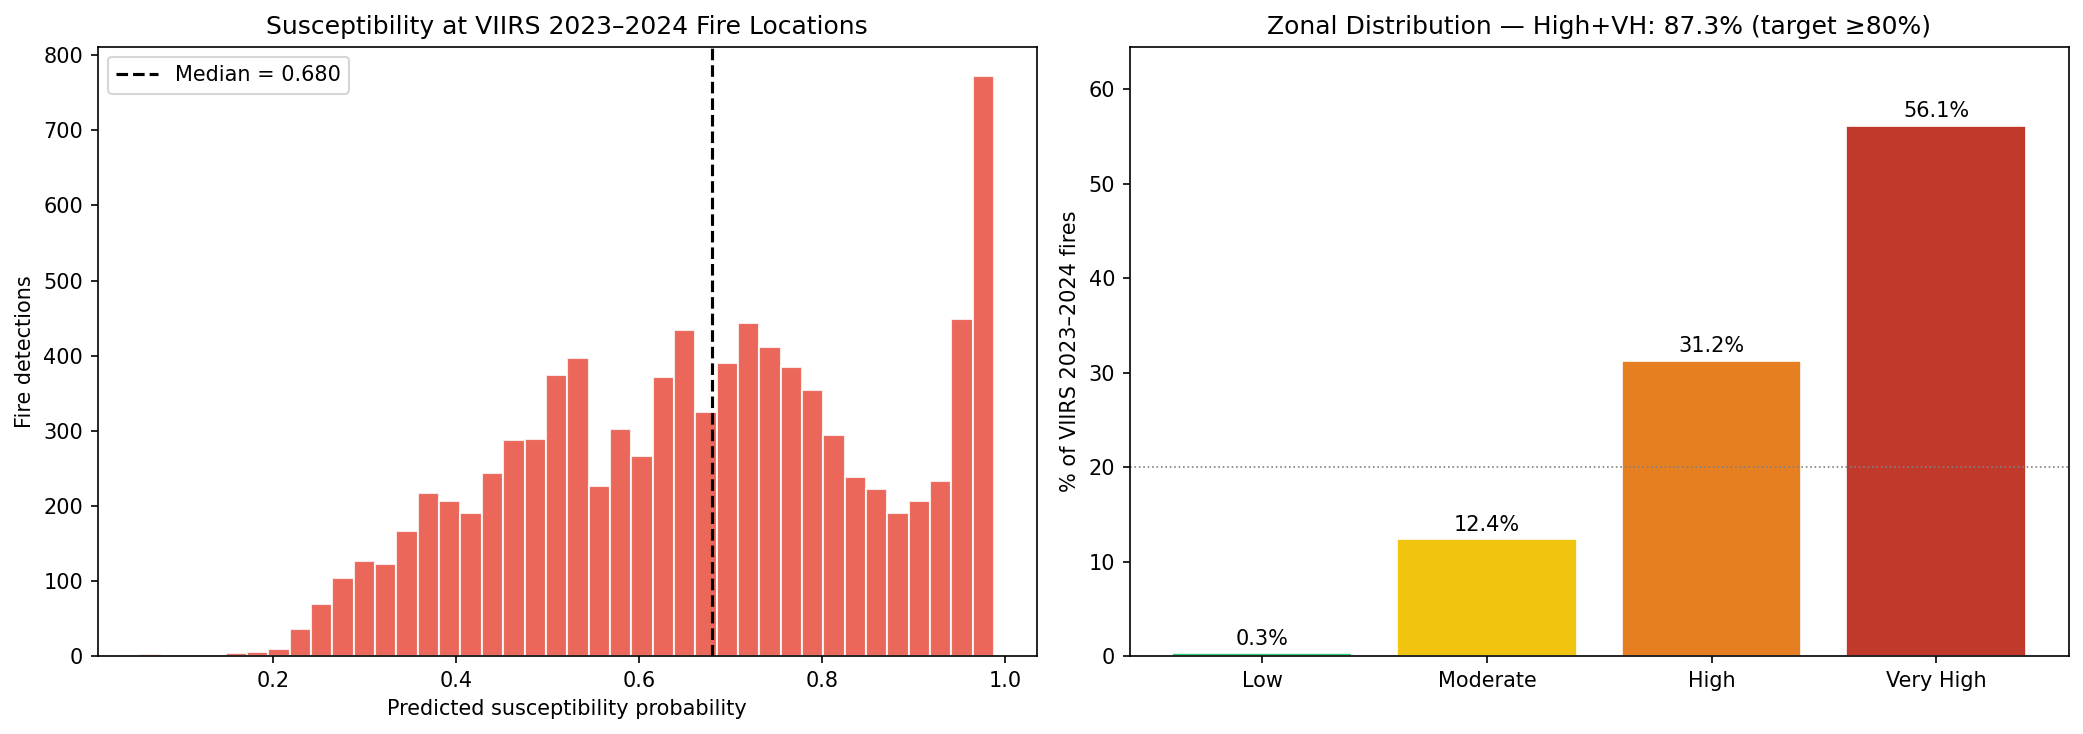

In [12]:
# @title Figura: estadísticas zonales de la validación VIIRS 2023–2024
from IPython.display import Image, display, HTML
display(HTML('<div style="font-family:JetBrains Mono,monospace;font-size:.75rem;color:#a3a3a3;letter-spacing:.4px;text-transform:uppercase;margin:18px 0 6px;border-left:3px solid #5bc8af;padding-left:10px">Fig. — 87.3% de los 9.377 focos VIIRS caen en zonas High + Very High (target ≥ 80%)</div>'))
display(Image(filename='../outputs/validation_zonal_stats.png'))
